# TSP Model and Basic Visualisation


This notebook develops a small Travelling Salesman Problem system from the basic TSP model to several metaheuristic and hyper-heuristic algorithms. It also includes route visualisation and an interactive interface for changing algorithm parameters.


In [97]:
import math
import random

import matplotlib.pyplot as plt
import ipywidgets as widgets

## 1. TSP Instance Generation

A random TSP instance is generated based on the number of cities selected by the user. Each city is represented by a randomly generated `(x, y)` coordinate.


In [98]:
def generate_cities(
    number_of_cities,
    coordinate_limit=100
):
    cities = []

    for city_index in range(
        number_of_cities
    ):
        x_coordinate = random.randint(
            0,
            coordinate_limit
        )

        y_coordinate = random.randint(
            0,
            coordinate_limit
        )

        cities.append(
            (
                x_coordinate,
                y_coordinate
            )
        )

    return cities

In [99]:
number_of_cities = 10
coordinate_limit = 100

cities = generate_cities(
    number_of_cities,
    coordinate_limit
)

### 1.1 Visualise the City Locations

The generated city coordinates are plotted before creating a route. This makes it easier to check the problem instance and see the position of each city.


In [100]:
def plot_cities(cities):
    x_coordinates = []
    y_coordinates = []

    for city in cities:
        x_coordinates.append(city[0])
        y_coordinates.append(city[1])

    plt.figure(figsize=(7, 7))
    plt.scatter(x_coordinates, y_coordinates)

    for city_index, city in enumerate(cities):
        plt.text(
            city[0] + 1,
            city[1] + 1,
            str(city_index)
        )

    plt.title("Generated TSP Cities")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True)
    plt.show()

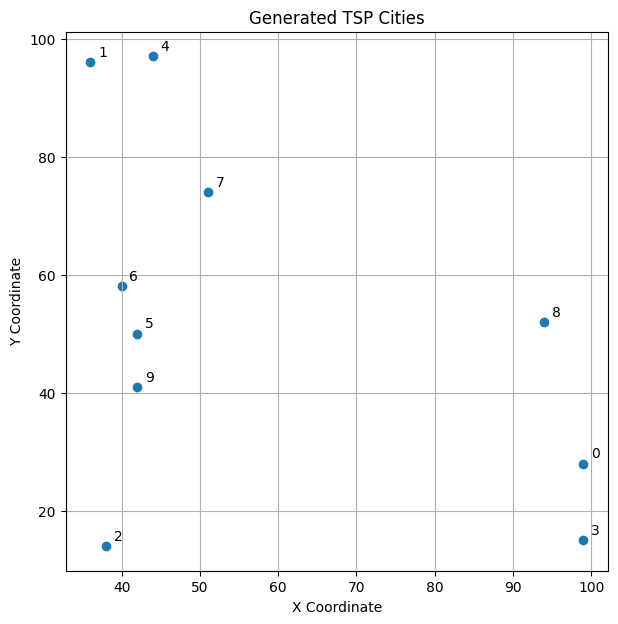

In [101]:
plot_cities(cities)

## 2. Tour Representation and Evaluation

A tour is stored as a list of city indices. The order of the indices represents the order in which the cities are visited.


### 2.1 Create an Initial Tour

The initial solution is created by placing all city indices in a list and randomly changing their order. This provides a starting solution for the search algorithms.


In [102]:
def create_initial_tour(number_of_cities):
    tour = list(range(number_of_cities))
    random.shuffle(tour)

    return tour

In [103]:
initial_tour = create_initial_tour(len(cities))
initial_tour

[0, 9, 2, 6, 7, 3, 5, 1, 8, 4]

### 2.2 Calculate the Tour Length

Euclidean distance is used to measure the distance between two cities. The complete tour length includes the distance between each pair of consecutive cities and the return from the final city to the starting city.


In [104]:
def calculate_distance(city_a, city_b):
    x_difference = city_a[0] - city_b[0]
    y_difference = city_a[1] - city_b[1]

    distance = math.sqrt(
        x_difference ** 2 + y_difference ** 2
    )

    return distance

The tour length function goes through the complete visiting order and adds each edge distance. The modulo operation connects the last city back to the first city, which closes the TSP tour.


In [105]:
def calculate_tour_length(tour, cities):
    total_distance = 0.0

    for index in range(len(tour)):
        current_city_index = tour[index]
        next_city_index = tour[(index + 1) % len(tour)]

        current_city = cities[current_city_index]
        next_city = cities[next_city_index]

        total_distance += calculate_distance(
            current_city,
            next_city
        )

    return total_distance

In [106]:
initial_tour_length = calculate_tour_length(
    initial_tour,
    cities
)

print("Initial tour:", initial_tour)
print("Initial tour length:", round(initial_tour_length, 2))

Initial tour: [0, 9, 2, 6, 7, 3, 5, 1, 8, 4]
Initial tour length: 566.86


### 2.3 Visualise a Tour

A tour is visualised by connecting the cities in their visiting order. The final city is connected back to the first city so that the complete closed route is shown.


In [107]:
def plot_tour(cities, tour, title="TSP Tour"):
    x_coordinates = []
    y_coordinates = []

    for city_index in tour:
        city = cities[city_index]
        x_coordinates.append(city[0])
        y_coordinates.append(city[1])

    first_city = cities[tour[0]]
    x_coordinates.append(first_city[0])
    y_coordinates.append(first_city[1])

    plt.figure(figsize=(7, 7))
    plt.plot(
        x_coordinates,
        y_coordinates,
        marker="o"
    )

    for city_index, city in enumerate(cities):
        plt.text(
            city[0] + 1,
            city[1] + 1,
            str(city_index)
        )

    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True)
    plt.show()

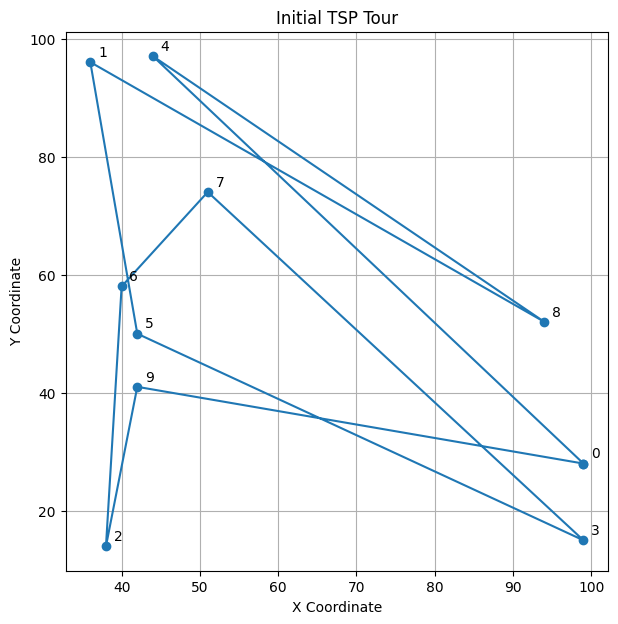

In [108]:
plot_tour(
    cities,
    initial_tour,
    title="Initial TSP Tour"
)

## 3. Low-Level Heuristic Operators

This section implements several simple operators that change the visiting order of cities and generate new candidate tours.


### 3.1 Delta Evaluation
### 3.1 增量距离计算

Instead of recalculating the complete tour length after every move, only the edges affected by the selected operator are recalculated. The new tour distance is obtained by removing the old affected edge distances and adding the new affected edge distances.

每次移动后不再重新计算整条路径长度，而只重新计算受到该算子影响的边。新的路径长度通过减去原来受影响的边距离，再加上新的边距离得到。

In [109]:
def calculate_edge_length(
    tour,
    position,
    cities
):
    number_of_cities = len(tour)

    current_city = tour[
        position % number_of_cities
    ]

    next_city = tour[
        (position + 1) % number_of_cities
    ]

    return calculate_distance(
        cities[current_city],
        cities[next_city]
    )


def calculate_updated_distance(
    current_tour,
    new_tour,
    current_distance,
    affected_positions,
    cities
):
    affected_positions = {
        position % len(current_tour)
        for position in affected_positions
    }

    old_distance = sum(
        calculate_edge_length(
            current_tour,
            position,
            cities
        )
        for position in affected_positions
    )

    new_distance = sum(
        calculate_edge_length(
            new_tour,
            position,
            cities
        )
        for position in affected_positions
    )

    return (
        current_distance
        - old_distance
        + new_distance
    )

### 3.2 Random Swap Operator

This operator randomly selects two positions in the tour and swaps the cities.


In [110]:
def random_swap(
    tour,
    current_distance,
    cities
):
    new_tour = tour.copy()

    first_position, second_position = (
        random.sample(
            range(len(new_tour)),
            2
        )
    )

    new_tour[
        first_position
    ], new_tour[
        second_position
    ] = (
        new_tour[second_position],
        new_tour[first_position]
    )

    affected_positions = [
        first_position - 1,
        first_position,
        second_position - 1,
        second_position
    ]

    new_distance = calculate_updated_distance(
        tour,
        new_tour,
        current_distance,
        affected_positions,
        cities
    )

    return new_tour, new_distance

In [111]:
swapped_tour, swapped_tour_length = random_swap(
    initial_tour,
    initial_tour_length,
    cities
)

print("Initial tour:", initial_tour)
print("Swapped tour:", swapped_tour)
print("Swapped tour length:", swapped_tour_length)

Initial tour: [0, 9, 2, 6, 7, 3, 5, 1, 8, 4]
Swapped tour: [0, 9, 2, 6, 7, 3, 4, 1, 8, 5]
Swapped tour length: 518.0165683778221


### 3.3 Adjacent Swap Operator

This operator swaps two neighbouring cities in the tour.


In [112]:
def adjacent_swap(
    tour,
    current_distance,
    cities
):
    new_tour = tour.copy()

    first_position = random.randint(
        0,
        len(new_tour) - 2
    )

    second_position = first_position + 1

    new_tour[
        first_position
    ], new_tour[
        second_position
    ] = (
        new_tour[second_position],
        new_tour[first_position]
    )

    affected_positions = [
        first_position - 1,
        first_position,
        second_position
    ]

    new_distance = calculate_updated_distance(
        tour,
        new_tour,
        current_distance,
        affected_positions,
        cities
    )

    return new_tour, new_distance

In [113]:
(
    adjacent_swapped_tour,
    adjacent_swapped_tour_length
) = adjacent_swap(
    initial_tour,
    initial_tour_length,
    cities
)

print("Initial tour:", initial_tour)
print(
    "Adjacent swapped tour:",
    adjacent_swapped_tour
)

Initial tour: [0, 9, 2, 6, 7, 3, 5, 1, 8, 4]
Adjacent swapped tour: [0, 9, 2, 7, 6, 3, 5, 1, 8, 4]


In [114]:
print(
    "Initial tour length:",
    round(initial_tour_length, 2)
)

print(
    "Adjacent swapped tour length:",
    round(adjacent_swapped_tour_length, 2)
)

Initial tour length: 566.86
Adjacent swapped tour length: 581.16


### 3.4 Insertion Operator

This operator removes one city from the tour and inserts it into another position.


In [115]:
def insertion(
    tour,
    current_distance,
    cities
):
    new_tour = tour.copy()

    remove_position, insert_position = (
        random.sample(
            range(len(new_tour)),
            2
        )
    )

    selected_city = new_tour[
        remove_position
    ]

    previous_city = new_tour[
        (remove_position - 1)
        % len(new_tour)
    ]

    next_city = new_tour[
        (remove_position + 1)
        % len(new_tour)
    ]

    new_distance = current_distance

    new_distance -= calculate_distance(
        cities[previous_city],
        cities[selected_city]
    )

    new_distance -= calculate_distance(
        cities[selected_city],
        cities[next_city]
    )

    new_distance += calculate_distance(
        cities[previous_city],
        cities[next_city]
    )

    new_tour.pop(remove_position)

    previous_insert_city = new_tour[
        (insert_position - 1)
        % len(new_tour)
    ]

    next_insert_city = new_tour[
        insert_position
        % len(new_tour)
    ]

    new_distance -= calculate_distance(
        cities[previous_insert_city],
        cities[next_insert_city]
    )

    new_distance += calculate_distance(
        cities[previous_insert_city],
        cities[selected_city]
    )

    new_distance += calculate_distance(
        cities[selected_city],
        cities[next_insert_city]
    )

    new_tour.insert(
        insert_position,
        selected_city
    )

    return new_tour, new_distance

In [116]:
(
    insertion_tour,
    insertion_tour_length
) = insertion(
    initial_tour,
    initial_tour_length,
    cities
)

print("Initial tour:", initial_tour)
print("Insertion tour:", insertion_tour)

Initial tour: [0, 9, 2, 6, 7, 3, 5, 1, 8, 4]
Insertion tour: [0, 9, 2, 6, 5, 7, 3, 1, 8, 4]


In [117]:
print(
    "Initial tour length:",
    round(initial_tour_length, 2)
)

print(
    "Insertion tour length:",
    round(insertion_tour_length, 2)
)

Initial tour length: 566.86
Insertion tour length: 570.66


### 3.5 Inversion Operator

This operator selects part of the tour and reverses the visiting order within that section.


In [118]:
def inversion(
    tour,
    current_distance,
    cities
):
    new_tour = tour.copy()

    start_position, end_position = sorted(
        random.sample(
            range(len(new_tour)),
            2
        )
    )

    new_tour[
        start_position:end_position + 1
    ] = reversed(
        new_tour[
            start_position:end_position + 1
        ]
    )

    affected_positions = [
        start_position - 1,
        end_position
    ]

    new_distance = calculate_updated_distance(
        tour,
        new_tour,
        current_distance,
        affected_positions,
        cities
    )

    return new_tour, new_distance

In [119]:
(
    inversion_tour,
    inversion_tour_length
) = inversion(
    initial_tour,
    initial_tour_length,
    cities
)

print("Initial tour:", initial_tour)
print("Inversion tour:", inversion_tour)

Initial tour: [0, 9, 2, 6, 7, 3, 5, 1, 8, 4]
Inversion tour: [9, 0, 2, 6, 7, 3, 5, 1, 8, 4]


In [120]:
print(
    "Initial tour length:",
    round(initial_tour_length, 2)
)

print(
    "Inversion tour length:",
    round(inversion_tour_length, 2)
)

Initial tour length: 566.86
Inversion tour length: 569.95


### 3.6 Compare Operator Results

The four candidate tours are stored together and plotted using the same visualisation function. This gives a simple comparison of how each operator changes the original tour.


In [121]:
operator_results = {
    "Random Swap": (
        swapped_tour,
        swapped_tour_length
    ),
    "Adjacent Swap": (
        adjacent_swapped_tour,
        adjacent_swapped_tour_length
    ),
    "Insertion": (
        insertion_tour,
        insertion_tour_length
    ),
    "Inversion": (
        inversion_tour,
        inversion_tour_length
    )
}

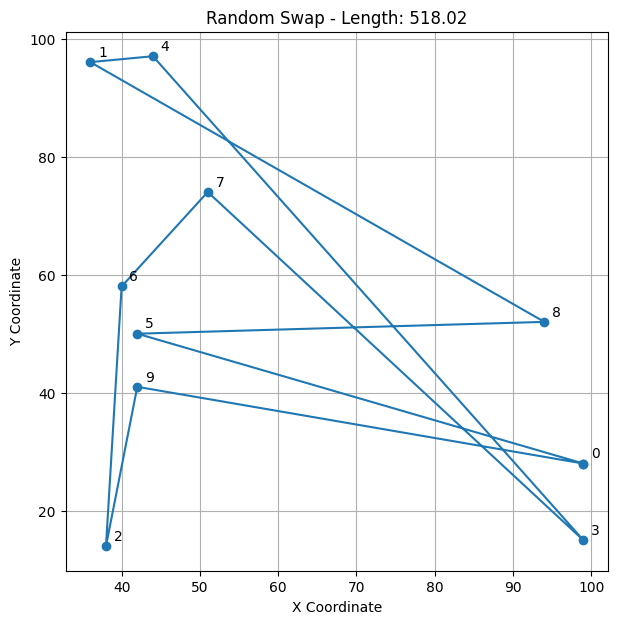

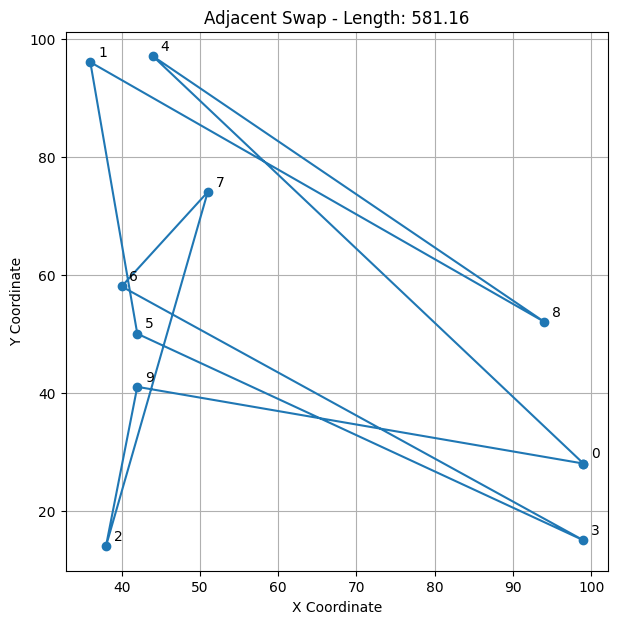

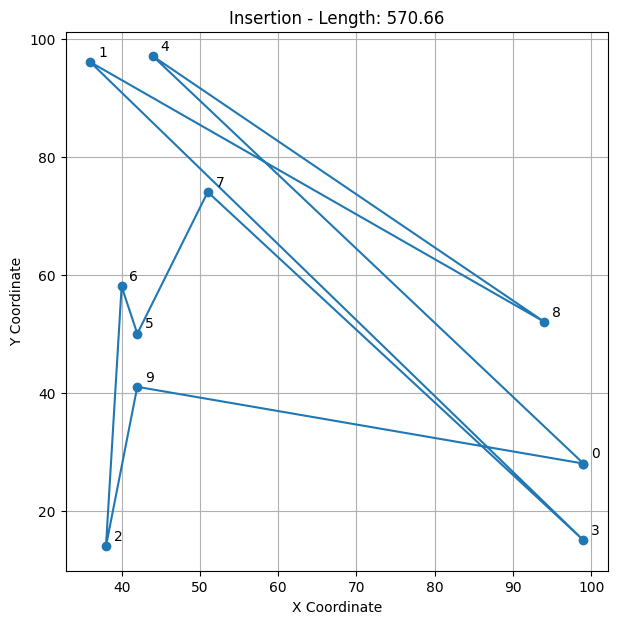

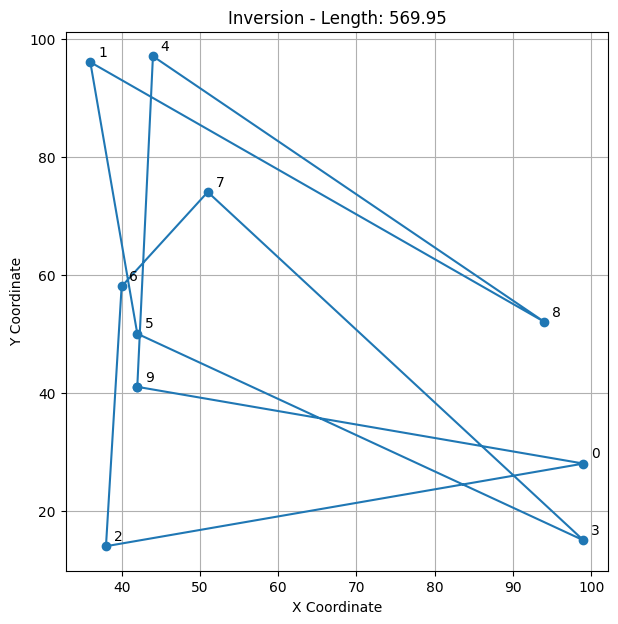

In [122]:
for (
    operator_name,
    (candidate_tour, candidate_length)
) in operator_results.items():

    plot_tour(
        cities,
        candidate_tour,
        title=(
            f"{operator_name} - "
            f"Length: {candidate_length:.2f}"
        )
    )

## 4. Simulated Annealing

Simulated Annealing improves a tour by repeatedly generating candidate solutions. It can sometimes accept a worse solution to avoid becoming trapped in a local optimum.


### 4.1 Algorithm Parameters

The main parameters control the temperature, cooling process and number of iterations. These values can be adjusted when running the algorithm.


In [123]:
initial_temperature = 1000.0
number_of_iterations = 1000

cooling_method = "geometric"

geometric_cooling_rate = 0.995
linear_cooling_amount = 1.0
lundy_mees_beta = 0.00001

In [124]:
def update_temperature(
    temperature,
    cooling_method,
    geometric_cooling_rate,
    linear_cooling_amount,
    lundy_mees_beta
):
    if cooling_method == "geometric":
        new_temperature = (
            temperature * geometric_cooling_rate
        )

    elif cooling_method == "linear":
        new_temperature = (
            temperature - linear_cooling_amount
        )

    elif cooling_method == "lundy_mees":
        new_temperature = temperature / (
            1 + lundy_mees_beta * temperature
        )

    else:
        raise ValueError("Unknown cooling method.")

    return max(new_temperature, 0.000001)

### 4.2 Acceptance Decision

A better candidate tour is always accepted. A worse candidate tour may also be accepted depending on the current temperature.


In [125]:
def should_accept(
    current_distance,
    candidate_distance,
    temperature
):
    if candidate_distance < current_distance:
        return True

    distance_difference = candidate_distance - current_distance

    acceptance_probability = math.exp(
        -distance_difference / temperature
    )

    return random.random() < acceptance_probability

### 4.3 Temperature Update

The temperature is reduced after each iteration. Three cooling methods are included: geometric, linear and Lundy–Mees cooling.


In [126]:
def update_temperature(
    temperature,
    cooling_method,
    geometric_cooling_rate,
    linear_cooling_amount,
    lundy_mees_beta
):
    if cooling_method == "geometric":
        new_temperature = (
            temperature * geometric_cooling_rate
        )

    elif cooling_method == "linear":
        new_temperature = (
            temperature - linear_cooling_amount
        )

    elif cooling_method == "lundy_mees":
        new_temperature = temperature / (
            1 + lundy_mees_beta * temperature
        )

    else:
        raise ValueError("Unknown cooling method.")

    return max(new_temperature, 0.000001)

### 4.4 Simulated Annealing Search

The algorithm repeatedly generates a candidate tour, applies the acceptance rule, updates the best solution and reduces the temperature.


In [127]:
def simulated_annealing(
    cities,
    initial_tour,
    initial_temperature,
    number_of_iterations,
    cooling_method,
    geometric_cooling_rate,
    linear_cooling_amount,
    lundy_mees_beta
):
    current_tour = initial_tour.copy()

    current_distance = calculate_tour_length(
        current_tour,
        cities
    )

    best_tour = current_tour.copy()
    best_distance = current_distance

    temperature = initial_temperature

    current_distance_history = [
        current_distance
    ]

    best_distance_history = [
        best_distance
    ]

    temperature_history = [
        temperature
    ]

    acceptance_history = []

    current_tour_history = [
        current_tour.copy()
    ]

    best_tour_history = [
        best_tour.copy()
    ]

    for iteration in range(
        number_of_iterations
    ):
        (
            candidate_tour,
            candidate_distance
        ) = inversion(
            current_tour,
            current_distance,
            cities
        )

        accepted = should_accept(
            current_distance,
            candidate_distance,
            temperature
        )

        if accepted:
            current_tour = candidate_tour
            current_distance = (
                candidate_distance
            )

        if current_distance < best_distance:
            best_tour = current_tour.copy()
            best_distance = current_distance

        current_distance_history.append(
            current_distance
        )

        best_distance_history.append(
            best_distance
        )

        acceptance_history.append(
            accepted
        )

        current_tour_history.append(
            current_tour.copy()
        )

        best_tour_history.append(
            best_tour.copy()
        )

        temperature = update_temperature(
            temperature,
            cooling_method,
            geometric_cooling_rate,
            linear_cooling_amount,
            lundy_mees_beta
        )

        temperature_history.append(
            temperature
        )

    return (
        best_tour,
        best_distance,
        current_distance_history,
        best_distance_history,
        temperature_history,
        acceptance_history,
        current_tour_history,
        best_tour_history
    )

The Simulated Annealing function is now run using the parameter values defined earlier. The returned values include the best solution, distance histories, temperature history, acceptance history and tour histories used for later visualisation.


In [128]:
(
    sa_best_tour,
    sa_best_distance,
    sa_current_history,
    sa_best_history,
    sa_temperature_history,
    sa_acceptance_history,
    sa_current_tour_history,
    sa_best_tour_history
) = simulated_annealing(
    cities,
    initial_tour,
    initial_temperature,
    number_of_iterations,
    cooling_method,
    geometric_cooling_rate,
    linear_cooling_amount,
    lundy_mees_beta
)

print("Initial tour length:", round(initial_tour_length, 2))
print("Best tour length:", round(sa_best_distance, 2))
print("Best tour:", sa_best_tour)

Initial tour length: 566.86
Best tour length: 261.68
Best tour: [6, 5, 9, 2, 3, 0, 8, 7, 4, 1]


In [129]:
def plot_tour_step(
    cities,
    tour_history,
    distance_history,
    step,
    title_prefix="Search Step"
):
    step_tour = tour_history[step]
    step_distance = distance_history[step]

    plt.figure(figsize=(6, 6))

    for city_index, (x, y) in enumerate(cities):
        plt.scatter(x, y)
        plt.text(x, y, str(city_index))

    for position in range(len(step_tour)):
        city_a = step_tour[position]
        city_b = step_tour[
            (position + 1) % len(step_tour)
        ]

        x_values = [
            cities[city_a][0],
            cities[city_b][0]
        ]

        y_values = [
            cities[city_a][1],
            cities[city_b][1]
        ]

        plt.plot(
            x_values,
            y_values
        )

    plt.title(
        f"{title_prefix} {step} "
        f"- Length: {step_distance:.2f}"
    )
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

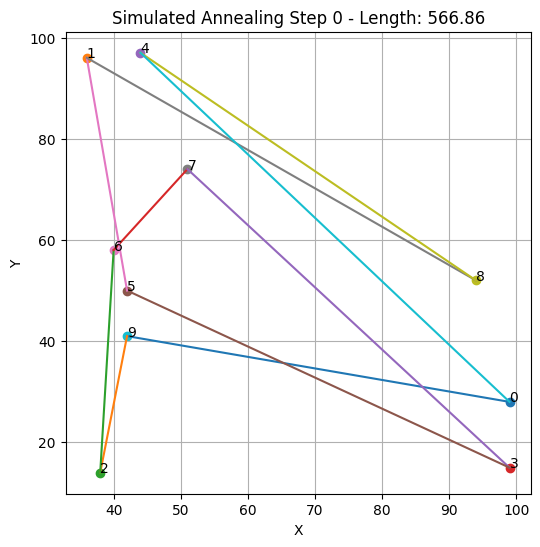

In [130]:
plot_tour_step(
    cities,
    sa_current_tour_history,
    sa_current_history,
    step=0,
    title_prefix="Simulated Annealing Step"
)

In [131]:
def show_sa_step(step):
    plot_tour_step(
        cities,
        sa_current_tour_history,
        sa_current_history,
        step=step,
        title_prefix="Simulated Annealing Step"
    )


sa_step_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(sa_current_tour_history) - 1,
    step=1,
    description="Step:",
    continuous_update=False
)

widgets.interact(
    show_sa_step,
    step=sa_step_slider
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Step:', max=1000), Output()), _…

<function __main__.show_sa_step(step)>

### 4.5 Search Process Animation

The animation displays the complete Simulated Annealing search process by updating the same route figure at every iteration.


In [132]:
import ipywidgets as widgets
from IPython.display import display

In [133]:
def display_tour_player(
    cities,
    tour_history,
    distance_history,
    title_prefix,
    interval=100
):
    import io

    play_button = widgets.Play(
        value=0,
        min=0,
        max=len(tour_history) - 1,
        step=1,
        interval=interval,
        description="Play"
    )

    iteration_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(tour_history) - 1,
        step=1,
        description="Iteration:",
        continuous_update=True
    )

    widgets.jslink(
        (play_button, "value"),
        (iteration_slider, "value")
    )

    route_image = widgets.Image(
        format="png",
        layout=widgets.Layout(
            width="450px"
        )
    )

    controls = widgets.HBox(
        [
            play_button,
            iteration_slider
        ]
    )

    player = widgets.VBox(
        [
            controls,
            route_image
        ]
    )

    display(player)

    x_coordinates = [
        city[0]
        for city in cities
    ]

    y_coordinates = [
        city[1]
        for city in cities
    ]

    def create_route_image(iteration):
        tour = tour_history[
            iteration
        ]

        closed_tour = (
            tour
            + [tour[0]]
        )

        route_x = [
            cities[city_index][0]
            for city_index
            in closed_tour
        ]

        route_y = [
            cities[city_index][1]
            for city_index
            in closed_tour
        ]

        figure, axis = plt.subplots(
            figsize=(4, 4)
        )

        axis.scatter(
            x_coordinates,
            y_coordinates
        )

        axis.plot(
            route_x,
            route_y,
            marker="o"
        )

        for city_index, city in enumerate(
            cities
        ):
            axis.text(
                city[0],
                city[1],
                str(city_index)
            )

        axis.set_xlim(
            min(x_coordinates) - 5,
            max(x_coordinates) + 5
        )

        axis.set_ylim(
            min(y_coordinates) - 5,
            max(y_coordinates) + 5
        )

        axis.set_xlabel("X")
        axis.set_ylabel("Y")
        axis.grid(True)

        axis.set_title(
            f"{title_prefix} "
            f"{iteration} "
            f"- Length: "
            f"{distance_history[iteration]:.2f}"
        )

        image_buffer = io.BytesIO()

        figure.savefig(
            image_buffer,
            format="png",
            bbox_inches="tight"
        )

        plt.close(
            figure
        )

        image_buffer.seek(0)

        return image_buffer.read()

    def update_route(change):
        iteration = change["new"]

        route_image.value = (
            create_route_image(
                iteration
            )
        )

    iteration_slider.observe(
        update_route,
        names="value"
    )

    route_image.value = (
        create_route_image(0)
    )

Before creating the animation, the search history is sampled to limit the total number of frames. The final iteration is always included so that the animation shows the final search state.


In [134]:
display_tour_player(
    cities=cities,
    tour_history=sa_current_tour_history,
    distance_history=sa_current_history,
    title_prefix="Simulated Annealing Iteration",
    interval=50
)

### 4.6 Simulated Annealing Results

The result section displays the best route and the main search histories. These outputs are used to compare the initial solution with the best solution found by the algorithm.


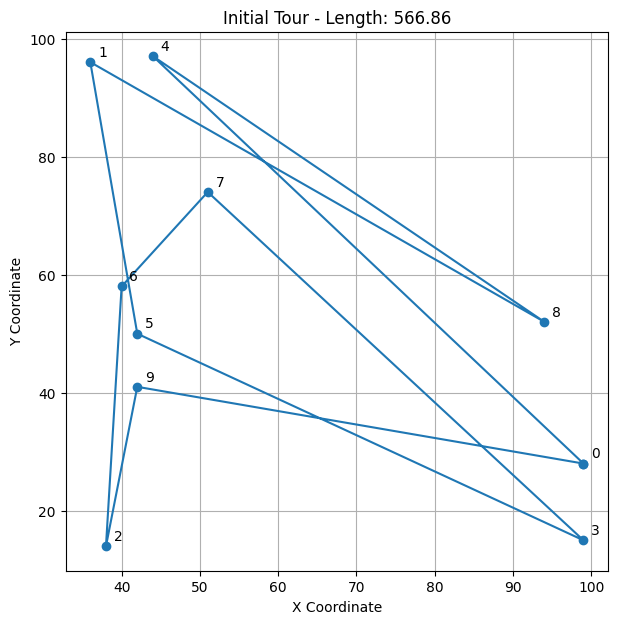

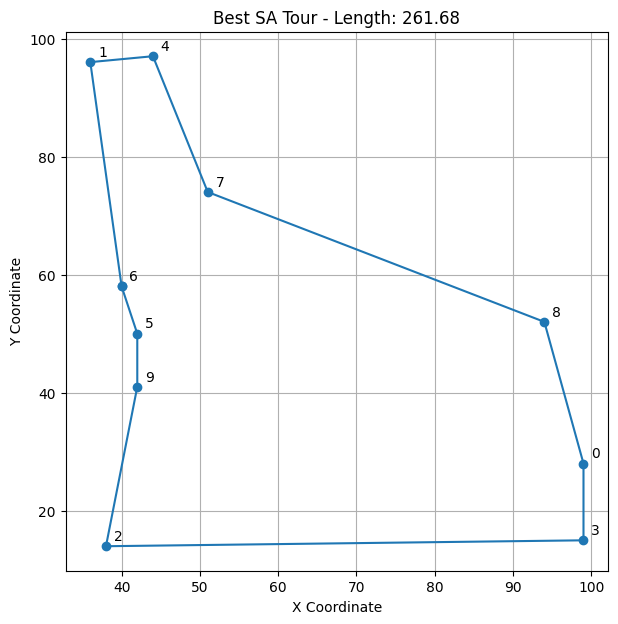

In [135]:
plot_tour(
    cities,
    initial_tour,
    title=f"Initial Tour - Length: {initial_tour_length:.2f}"
)

plot_tour(
    cities,
    sa_best_tour,
    title=f"Best SA Tour - Length: {sa_best_distance:.2f}"
)

The current distance and best distance are plotted across all iterations. The current distance may sometimes increase because Simulated Annealing can accept a worse candidate, while the best distance can only stay the same or decrease.


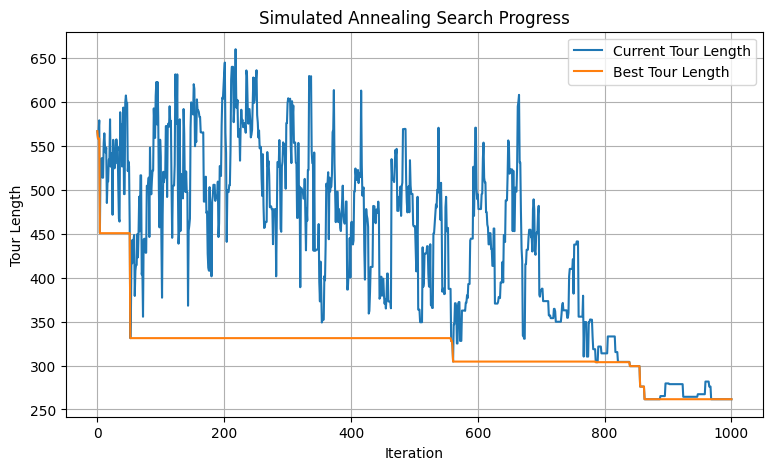

In [136]:
plt.figure(figsize=(9, 5))

plt.plot(
    sa_current_history,
    label="Current Tour Length"
)

plt.plot(
    sa_best_history,
    label="Best Tour Length"
)

plt.title("Simulated Annealing Search Progress")
plt.xlabel("Iteration")
plt.ylabel("Tour Length")
plt.legend()
plt.grid(True)
plt.show()

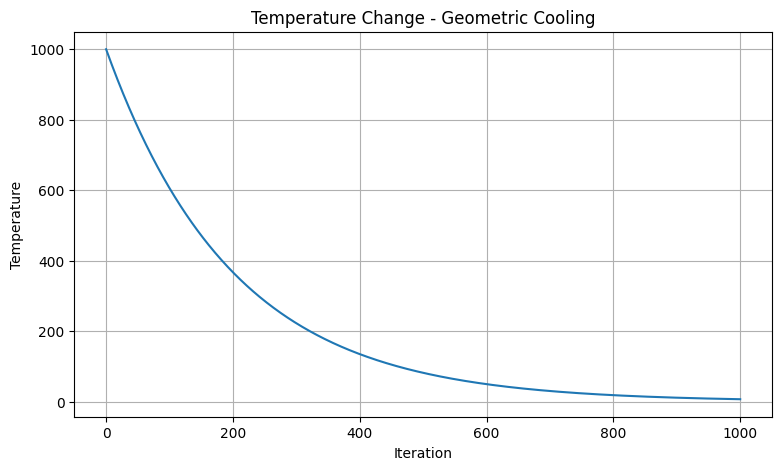

In [137]:
plt.figure(figsize=(9, 5))

plt.plot(sa_temperature_history)

plt.title(
    f"Temperature Change - {cooling_method.title()} Cooling"
)
plt.xlabel("Iteration")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

In [138]:
accepted_moves = sum(sa_acceptance_history)
rejected_moves = (
    len(sa_acceptance_history) - accepted_moves
)

print("Accepted moves:", accepted_moves)
print("Rejected moves:", rejected_moves)

Accepted moves: 668
Rejected moves: 332


## 5. Great Deluge

Great Deluge accepts a candidate tour when its distance is below the current water level. The water level is gradually reduced during the search.


### 5.1 Algorithm Parameters

The parameters control the initial water level, water level reduction and number of iterations.


In [139]:
great_deluge_iterations = 1000
water_level_ratio = 1.2
water_level_reduction = 0.3

### 5.2 Acceptance Decision

A candidate tour is accepted when its distance is below the current water level.


In [140]:
def great_deluge_acceptance(
    candidate_distance,
    water_level
):
    return candidate_distance <= water_level

### 5.3 Water Level Update

The water level is reduced by a fixed amount after each iteration.


In [141]:
def update_water_level(
    water_level,
    water_level_reduction
):
    new_water_level = water_level - water_level_reduction

    return max(new_water_level, 0.0)

### 5.4 Great Deluge Search

The algorithm generates candidate tours, accepts solutions below the current water level, and gradually reduces the water level.


In [142]:
def great_deluge(
    cities,
    initial_tour,
    number_of_iterations,
    water_level_ratio,
    water_level_reduction
):
    current_tour = initial_tour.copy()

    current_distance = calculate_tour_length(
        current_tour,
        cities
    )

    best_tour = current_tour.copy()
    best_distance = current_distance

    water_level = (
        current_distance
        * water_level_ratio
    )

    current_distance_history = [
        current_distance
    ]

    best_distance_history = [
        best_distance
    ]

    water_level_history = [
        water_level
    ]

    acceptance_history = []

    current_tour_history = [
        current_tour.copy()
    ]

    best_tour_history = [
        best_tour.copy()
    ]

    for iteration in range(
        number_of_iterations
    ):
        (
            candidate_tour,
            candidate_distance
        ) = inversion(
            current_tour,
            current_distance,
            cities
        )

        accepted = great_deluge_acceptance(
            candidate_distance,
            water_level
        )

        if accepted:
            current_tour = candidate_tour
            current_distance = (
                candidate_distance
            )

        if (
            current_distance
            < best_distance
        ):
            best_tour = (
                current_tour.copy()
            )

            best_distance = (
                current_distance
            )

        current_distance_history.append(
            current_distance
        )

        best_distance_history.append(
            best_distance
        )

        acceptance_history.append(
            accepted
        )

        current_tour_history.append(
            current_tour.copy()
        )

        best_tour_history.append(
            best_tour.copy()
        )

        water_level = update_water_level(
            water_level,
            water_level_reduction
        )

        water_level_history.append(
            water_level
        )

    return (
        best_tour,
        best_distance,
        current_distance_history,
        best_distance_history,
        water_level_history,
        acceptance_history,
        current_tour_history,
        best_tour_history
    )

The Great Deluge function is now called using the parameter values defined earlier. The returned values include the best solution, distance histories, water level history and acceptance history.


In [143]:
(
    gd_best_tour,
    gd_best_distance,
    gd_current_history,
    gd_best_history,
    gd_water_level_history,
    gd_acceptance_history,
    gd_current_tour_history,
    gd_best_tour_history
) = great_deluge(
    cities,
    initial_tour,
    great_deluge_iterations,
    water_level_ratio,
    water_level_reduction
)

print(
    "Initial tour length:",
    round(initial_tour_length, 2)
)

print(
    "Best tour length:",
    round(gd_best_distance, 2)
)

print(
    "Best tour:",
    gd_best_tour
)

Initial tour length: 566.86
Best tour length: 293.41
Best tour: [7, 5, 9, 2, 3, 0, 8, 4, 1, 6]


### 5.5 Great Deluge Results

The initial tour, best tour, search progress and water level changes are displayed to show the behaviour of the algorithm.


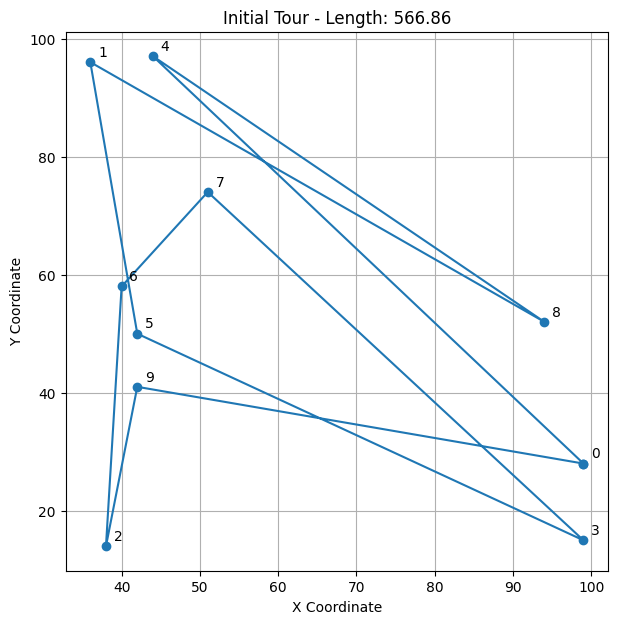

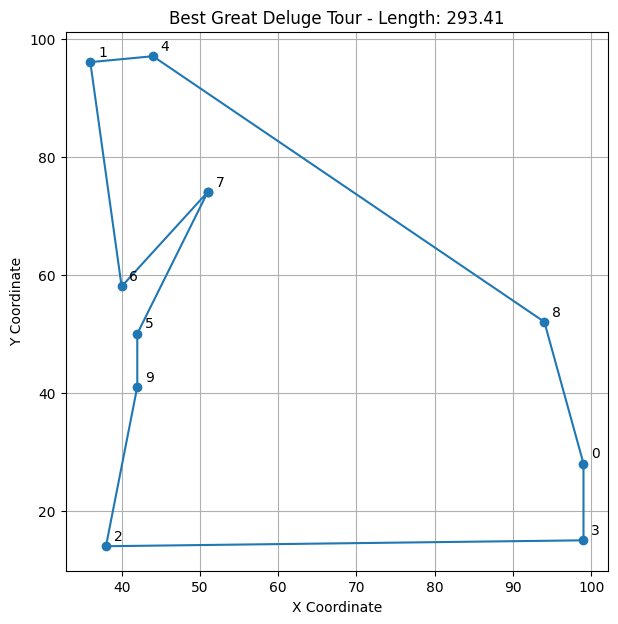

In [144]:
plot_tour(
    cities,
    initial_tour,
    title=f"Initial Tour - Length: {initial_tour_length:.2f}"
)

plot_tour(
    cities,
    gd_best_tour,
    title=f"Best Great Deluge Tour - Length: {gd_best_distance:.2f}"
)

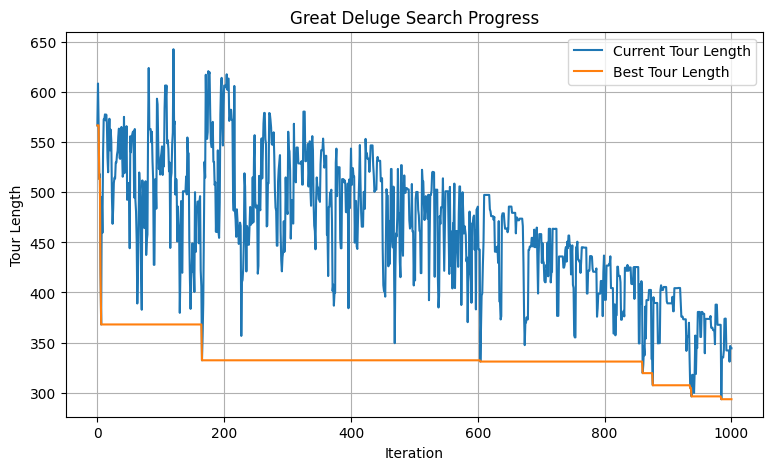

In [145]:
plt.figure(figsize=(9, 5))

plt.plot(
    gd_current_history,
    label="Current Tour Length"
)

plt.plot(
    gd_best_history,
    label="Best Tour Length"
)

plt.title("Great Deluge Search Progress")
plt.xlabel("Iteration")
plt.ylabel("Tour Length")
plt.legend()
plt.grid(True)
plt.show()

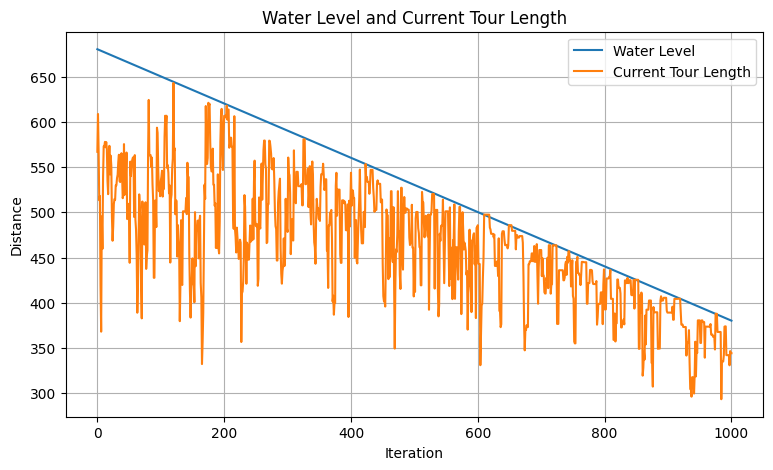

In [146]:
plt.figure(figsize=(9, 5))

plt.plot(
    gd_water_level_history,
    label="Water Level"
)

plt.plot(
    gd_current_history,
    label="Current Tour Length"
)

plt.title("Water Level and Current Tour Length")
plt.xlabel("Iteration")
plt.ylabel("Distance")
plt.legend()
plt.grid(True)
plt.show()

In [147]:
accepted_moves = sum(gd_acceptance_history)
rejected_moves = (
    len(gd_acceptance_history) - accepted_moves
)

print("Accepted moves:", accepted_moves)
print("Rejected moves:", rejected_moves)

Accepted moves: 784
Rejected moves: 216


In [148]:
distance_improvement = (
    initial_tour_length - gd_best_distance
)

improvement_percentage = (
    distance_improvement / initial_tour_length
) * 100

print(
    "Distance improvement:",
    round(distance_improvement, 2)
)

print(
    "Improvement percentage:",
    round(improvement_percentage, 2),
    "%"
)

Distance improvement: 273.46
Improvement percentage: 48.24 %


## 6. Iterated Local Search

Iterated Local Search improves a solution using local search and then applies a perturbation to continue exploring other areas.


### 6.1 Algorithm Parameters

The parameters control the number of iterations, local search method and perturbation method.


In [149]:
ils_iterations = 100

local_search_method = "first_improvement"
perturbation_method = "random_swap"

number_of_swaps = 3

### 6.2 First Improvement Local Search

This method checks neighbouring tours and accepts the first tour that improves the current solution.


In [150]:
def first_improvement(
    cities,
    tour,
    tour_distance,
    record_history=False
):
    current_tour = tour.copy()
    current_distance = tour_distance

    tour_history = [
        current_tour.copy()
    ]

    distance_history = [
        current_distance
    ]

    improvement_found = True

    while improvement_found:
        improvement_found = False

        for start_position in range(
            len(current_tour) - 1
        ):
            for end_position in range(
                start_position + 1,
                len(current_tour)
            ):
                candidate_tour = (
                    current_tour.copy()
                )

                candidate_tour[
                    start_position:
                    end_position + 1
                ] = reversed(
                    candidate_tour[
                        start_position:
                        end_position + 1
                    ]
                )

                affected_positions = [
                    start_position - 1,
                    end_position
                ]

                candidate_distance = (
                    calculate_updated_distance(
                        current_tour,
                        candidate_tour,
                        current_distance,
                        affected_positions,
                        cities
                    )
                )

                if (
                    candidate_distance
                    < current_distance
                ):
                    current_tour = (
                        candidate_tour
                    )

                    current_distance = (
                        candidate_distance
                    )

                    tour_history.append(
                        current_tour.copy()
                    )

                    distance_history.append(
                        current_distance
                    )

                    improvement_found = True
                    break

            if improvement_found:
                break

    if record_history:
        return (
            current_tour,
            current_distance,
            tour_history,
            distance_history
        )

    return (
        current_tour,
        current_distance
    )

### 6.3 Best Improvement Local Search

This method checks all neighbouring tours and selects the best improvement found.


In [151]:
def best_improvement(
    cities,
    tour,
    tour_distance,
    record_history=False
):
    current_tour = tour.copy()
    current_distance = tour_distance

    tour_history = [
        current_tour.copy()
    ]

    distance_history = [
        current_distance
    ]

    improvement_found = True

    while improvement_found:
        improvement_found = False

        best_candidate_tour = (
            current_tour.copy()
        )

        best_candidate_distance = (
            current_distance
        )

        for start_position in range(
            len(current_tour) - 1
        ):
            for end_position in range(
                start_position + 1,
                len(current_tour)
            ):
                candidate_tour = (
                    current_tour.copy()
                )

                candidate_tour[
                    start_position:
                    end_position + 1
                ] = reversed(
                    candidate_tour[
                        start_position:
                        end_position + 1
                    ]
                )

                affected_positions = [
                    start_position - 1,
                    end_position
                ]

                candidate_distance = (
                    calculate_updated_distance(
                        current_tour,
                        candidate_tour,
                        current_distance,
                        affected_positions,
                        cities
                    )
                )

                if (
                    candidate_distance
                    < best_candidate_distance
                ):
                    best_candidate_tour = (
                        candidate_tour
                    )

                    best_candidate_distance = (
                        candidate_distance
                    )

                    improvement_found = True

        if improvement_found:
            current_tour = (
                best_candidate_tour
            )

            current_distance = (
                best_candidate_distance
            )

            tour_history.append(
                current_tour.copy()
            )

            distance_history.append(
                current_distance
            )

    if record_history:
        return (
            current_tour,
            current_distance,
            tour_history,
            distance_history
        )

    return (
        current_tour,
        current_distance
    )

### 6.4 Perturbation Methods

The perturbation step changes the current tour so that the search can move to a different area.


In [152]:
def perturb_tour(
    tour,
    tour_distance,
    cities,
    perturbation_method,
    number_of_swaps
):
    if perturbation_method == "random_swap":
        (
            perturbed_tour,
            perturbed_distance
        ) = random_swap(
            tour,
            tour_distance,
            cities
        )

    elif (
        perturbation_method
        == "multiple_random_swaps"
    ):
        perturbed_tour = tour.copy()
        perturbed_distance = tour_distance

        for swap_index in range(
            number_of_swaps
        ):
            (
                perturbed_tour,
                perturbed_distance
            ) = random_swap(
                perturbed_tour,
                perturbed_distance,
                cities
            )

    else:
        raise ValueError(
            "Unknown perturbation method."
        )

    return (
        perturbed_tour,
        perturbed_distance
    )

### 6.5 Iterated Local Search

The algorithm applies local search, perturbs the improved tour and continues the search from the new solution.


In [153]:
def iterated_local_search(
    cities,
    initial_tour,
    number_of_iterations,
    local_search_method,
    perturbation_method,
    number_of_swaps
):
    current_tour = initial_tour.copy()

    current_distance = calculate_tour_length(
        current_tour,
        cities
    )

    best_tour = current_tour.copy()
    best_distance = current_distance


    current_distance_history = [
        current_distance
    ]

    best_distance_history = [
        best_distance
    ]

    current_tour_history = [
        current_tour.copy()
    ]

    best_tour_history = [
        best_tour.copy()
    ]


    # Initial local search
    if (
        local_search_method
        == "first_improvement"
    ):
        (
            current_tour,
            current_distance,
            local_tour_history,
            local_distance_history
        ) = first_improvement(
            cities,
            current_tour,
            current_distance,
            record_history=True
        )

    elif (
        local_search_method
        == "best_improvement"
    ):
        (
            current_tour,
            current_distance,
            local_tour_history,
            local_distance_history
        ) = best_improvement(
            cities,
            current_tour,
            current_distance,
            record_history=True
        )

    else:
        raise ValueError(
            "Unknown local search method."
        )


    # Add every internal local-search step
    for history_index in range(
        1,
        len(local_tour_history)
    ):
        history_tour = (
            local_tour_history[
                history_index
            ].copy()
        )

        history_distance = (
            local_distance_history[
                history_index
            ]
        )

        if (
            history_distance
            < best_distance
        ):
            best_tour = (
                history_tour.copy()
            )

            best_distance = (
                history_distance
            )

        current_tour_history.append(
            history_tour.copy()
        )

        current_distance_history.append(
            history_distance
        )

        best_tour_history.append(
            best_tour.copy()
        )

        best_distance_history.append(
            best_distance
        )


    for iteration in range(
        number_of_iterations
    ):

        (
            perturbed_tour,
            perturbed_distance
        ) = perturb_tour(
            current_tour,
            current_distance,
            cities,
            perturbation_method,
            number_of_swaps
        )


        if (
            local_search_method
            == "first_improvement"
        ):
            (
                candidate_tour,
                candidate_distance,
                local_tour_history,
                local_distance_history
            ) = first_improvement(
                cities,
                perturbed_tour,
                perturbed_distance,
                record_history=True
            )

        elif (
            local_search_method
            == "best_improvement"
        ):
            (
                candidate_tour,
                candidate_distance,
                local_tour_history,
                local_distance_history
            ) = best_improvement(
                cities,
                perturbed_tour,
                perturbed_distance,
                record_history=True
            )


        for history_index in range(
            1,
            len(local_tour_history)
        ):
            history_tour = (
                local_tour_history[
                    history_index
                ].copy()
            )

            history_distance = (
                local_distance_history[
                    history_index
                ]
            )

            current_tour_history.append(
                history_tour.copy()
            )

            current_distance_history.append(
                history_distance
            )

            if (
                history_distance
                < best_distance
            ):
                best_tour = (
                    history_tour.copy()
                )

                best_distance = (
                    history_distance
                )

            best_tour_history.append(
                best_tour.copy()
            )

            best_distance_history.append(
                best_distance
            )


        if (
            candidate_distance
            < current_distance
        ):
            current_tour = (
                candidate_tour
            )

            current_distance = (
                candidate_distance
            )


        if (
            current_distance
            < best_distance
        ):
            best_tour = (
                current_tour.copy()
            )

            best_distance = (
                current_distance
            )


    return (
        best_tour,
        best_distance,
        current_distance_history,
        best_distance_history,
        current_tour_history,
        best_tour_history
    )

In [154]:
(
    ils_best_tour,
    ils_best_distance,
    ils_current_history,
    ils_best_history,
    ils_current_tour_history,
    ils_best_tour_history
) = iterated_local_search(
    cities,
    initial_tour,
    ils_iterations,
    local_search_method,
    perturbation_method,
    number_of_swaps
)

print(
    "Initial tour length:",
    round(initial_tour_length, 2)
)

print(
    "Best tour length:",
    round(ils_best_distance, 2)
)

print(
    "Best tour:",
    ils_best_tour
)

Initial tour length: 566.86
Best tour length: 261.68
Best tour: [2, 3, 0, 8, 7, 4, 1, 6, 5, 9]


### 6.6 Iterated Local Search Results

The initial tour, best tour and search progress are displayed to show the result of Iterated Local Search.


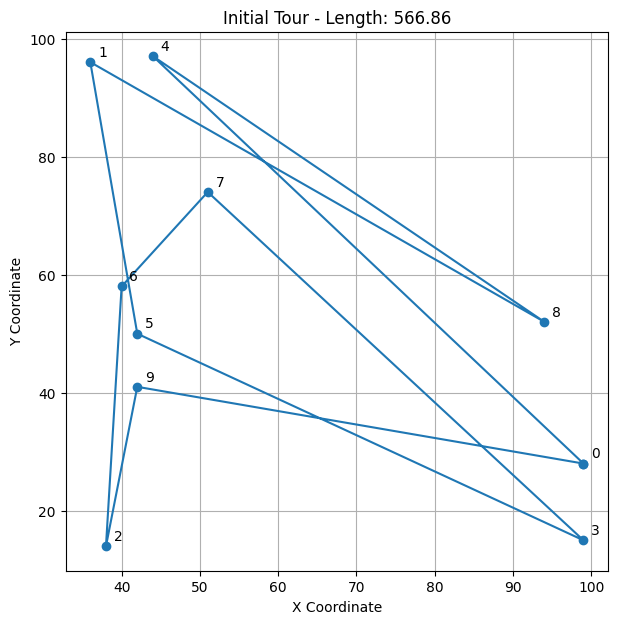

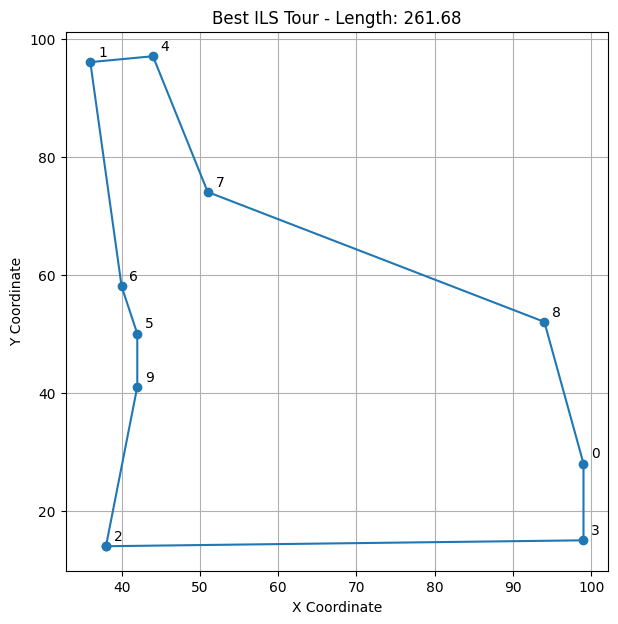

In [155]:
plot_tour(
    cities,
    initial_tour,
    title=f"Initial Tour - Length: {initial_tour_length:.2f}"
)

plot_tour(
    cities,
    ils_best_tour,
    title=f"Best ILS Tour - Length: {ils_best_distance:.2f}"
)

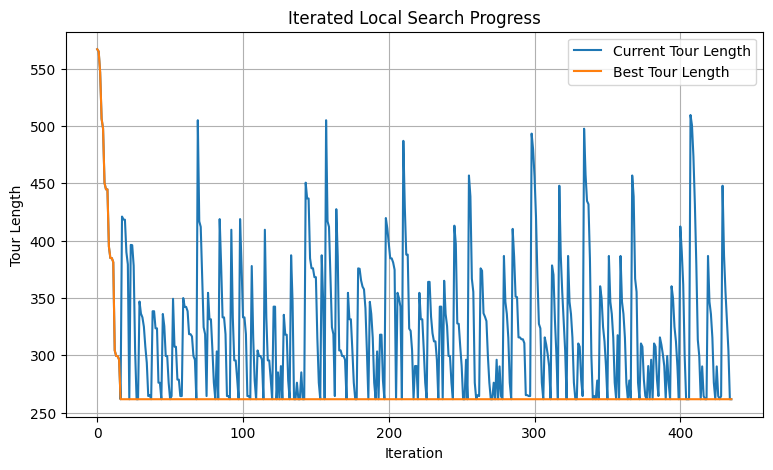

In [156]:
plt.figure(figsize=(9, 5))

plt.plot(
    ils_current_history,
    label="Current Tour Length"
)

plt.plot(
    ils_best_history,
    label="Best Tour Length"
)

plt.title("Iterated Local Search Progress")
plt.xlabel("Iteration")
plt.ylabel("Tour Length")
plt.legend()
plt.grid(True)
plt.show()

In [157]:
ils_distance_improvement = (
    initial_tour_length - ils_best_distance
)

ils_improvement_percentage = (
    ils_distance_improvement / initial_tour_length
) * 100

print(
    "Distance improvement:",
    round(ils_distance_improvement, 2)
)

print(
    "Improvement percentage:",
    round(ils_improvement_percentage, 2),
    "%"
)

Distance improvement: 305.19
Improvement percentage: 53.84 %


## 7. Selection Hyper-heuristic

The Selection Hyper-heuristic selects low-level heuristics during the search and uses a move acceptance method to decide whether a candidate tour should be accepted.


### 7.1 Algorithm Parameters

The parameters control the number of iterations, heuristic selection method and move acceptance method.


In [158]:
hyper_heuristic_iterations = 1000

heuristic_selection_method = "reinforcement_learning"
move_acceptance_method = "only_improving"

tournament_size = 2
learning_rate = 1.0

### 7.2 Low-Level Heuristics

The low-level heuristics generate candidate tours by changing the visiting order of cities.


In [159]:
def hh_first_improvement(
    tour,
    current_distance,
    cities
):
    number_of_cities = len(tour)

    for start_position in range(
        number_of_cities - 1
    ):
        for end_position in range(
            start_position + 1,
            number_of_cities
        ):
            candidate_tour = tour.copy()

            candidate_tour[
                start_position:end_position + 1
            ] = reversed(
                candidate_tour[
                    start_position:end_position + 1
                ]
            )

            affected_positions = [
                start_position - 1,
                end_position
            ]

            candidate_distance = (
                calculate_updated_distance(
                    tour,
                    candidate_tour,
                    current_distance,
                    affected_positions,
                    cities
                )
            )

            if (
                candidate_distance
                < current_distance
            ):
                return (
                    candidate_tour,
                    candidate_distance
                )

    return (
        tour.copy(),
        current_distance
    )


def hh_best_improvement(
    tour,
    current_distance,
    cities
):
    best_tour = tour.copy()
    best_distance = current_distance

    number_of_cities = len(tour)

    for start_position in range(
        number_of_cities - 1
    ):
        for end_position in range(
            start_position + 1,
            number_of_cities
        ):
            candidate_tour = tour.copy()

            candidate_tour[
                start_position:end_position + 1
            ] = reversed(
                candidate_tour[
                    start_position:end_position + 1
                ]
            )

            affected_positions = [
                start_position - 1,
                end_position
            ]

            candidate_distance = (
                calculate_updated_distance(
                    tour,
                    candidate_tour,
                    current_distance,
                    affected_positions,
                    cities
                )
            )

            if (
                candidate_distance
                < best_distance
            ):
                best_tour = (
                    candidate_tour
                )

                best_distance = (
                    candidate_distance
                )

    return (
        best_tour,
        best_distance
    )


def davis_hill_climbing(
    tour,
    current_distance,
    cities
):
    current_tour = tour.copy()
    current_tour_distance = (
        current_distance
    )

    number_of_cities = len(
        current_tour
    )

    move_positions = []

    for start_position in range(
        number_of_cities - 1
    ):
        for end_position in range(
            start_position + 1,
            number_of_cities
        ):
            move_positions.append(
                (
                    start_position,
                    end_position
                )
            )

    random.shuffle(
        move_positions
    )

    for (
        start_position,
        end_position
    ) in move_positions:
        candidate_tour = (
            current_tour.copy()
        )

        candidate_tour[
            start_position:end_position + 1
        ] = reversed(
            candidate_tour[
                start_position:end_position + 1
            ]
        )

        affected_positions = [
            start_position - 1,
            end_position
        ]

        candidate_distance = (
            calculate_updated_distance(
                current_tour,
                candidate_tour,
                current_tour_distance,
                affected_positions,
                cities
            )
        )

        if (
            candidate_distance
            < current_tour_distance
        ):
            current_tour = (
                candidate_tour
            )

            current_tour_distance = (
                candidate_distance
            )

    return (
        current_tour,
        current_tour_distance
    )

In [160]:
def apply_low_level_heuristic(
    tour,
    tour_distance,
    cities,
    heuristic_name
):
    if heuristic_name == "random_swap":
        (
            candidate_tour,
            candidate_distance
        ) = random_swap(
            tour,
            tour_distance,
            cities
        )

    elif (
        heuristic_name
        == "adjacent_swap"
    ):
        (
            candidate_tour,
            candidate_distance
        ) = adjacent_swap(
            tour,
            tour_distance,
            cities
        )

    elif heuristic_name == "insertion":
        (
            candidate_tour,
            candidate_distance
        ) = insertion(
            tour,
            tour_distance,
            cities
        )

    elif heuristic_name == "inversion":
        (
            candidate_tour,
            candidate_distance
        ) = inversion(
            tour,
            tour_distance,
            cities
        )

    elif (
        heuristic_name
        == "first_improvement"
    ):
        (
            candidate_tour,
            candidate_distance
        ) = hh_first_improvement(
            tour,
            tour_distance,
            cities
        )

    elif (
        heuristic_name
        == "best_improvement"
    ):
        (
            candidate_tour,
            candidate_distance
        ) = hh_best_improvement(
            tour,
            tour_distance,
            cities
        )

    elif (
        heuristic_name
        == "davis_hill_climbing"
    ):
        (
            candidate_tour,
            candidate_distance
        ) = davis_hill_climbing(
            tour,
            tour_distance,
            cities
        )

    else:
        raise ValueError(
            "Unknown low-level heuristic."
        )

    return (
        candidate_tour,
        candidate_distance
    )

The heuristic names are stored in one list. Each heuristic is tested once using the initial tour to check that the dispatcher function applies the correct operator.


In [161]:
heuristic_names = [
    "random_swap",
    "adjacent_swap",
    "insertion",
    "inversion"
]

for heuristic_name in heuristic_names:
    (
        candidate_tour,
        candidate_distance
    ) = apply_low_level_heuristic(
        initial_tour,
        initial_tour_length,
        cities,
        heuristic_name
    )

    print(
        heuristic_name,
        "- Tour length:",
        round(candidate_distance, 2)
    )

random_swap - Tour length: 462.12
adjacent_swap - Tour length: 438.4
insertion - Tour length: 454.06
inversion - Tour length: 513.31


### 7.3 Reinforcement Learning with Tournament Selection

Each low-level heuristic has a score. Tournament Selection compares a small group of heuristics and selects the one with the highest score.


In [162]:
def initialise_heuristic_scores(
    available_heuristics
):
    return {
        heuristic_name: 0.0
        for heuristic_name
        in available_heuristics
    }

Tournament Selection randomly chooses a small group of heuristics and selects the heuristic with the highest score in that group. This keeps some randomness in the selection process.


In [163]:
def tournament_selection(
    heuristic_scores,
    tournament_size
):
    heuristic_names = list(
        heuristic_scores.keys()
    )

    if len(heuristic_names) == 0:
        raise ValueError(
            "At least one low-level heuristic must be selected."
        )

    actual_tournament_size = min(
        tournament_size,
        len(heuristic_names)
    )

    selected_heuristics = random.sample(
        heuristic_names,
        actual_tournament_size
    )

    selected_heuristic = max(
        selected_heuristics,
        key=lambda name: heuristic_scores[name]
    )

    return selected_heuristic

After a heuristic generates a candidate tour, its score is updated. A better candidate receives a full reward, an accepted non-improving candidate receives a smaller reward, and a rejected candidate receives a penalty.


In [164]:
def update_heuristic_score(
    heuristic_scores,
    heuristic_name,
    current_distance,
    candidate_distance,
    accepted,
    learning_rate
):
    if candidate_distance < current_distance:
        heuristic_scores[heuristic_name] += learning_rate

    elif accepted:
        heuristic_scores[heuristic_name] += (
            learning_rate * 0.5
        )

    else:
        heuristic_scores[heuristic_name] -= (
            learning_rate * 0.5
        )

### 7.4 Choice Function

The Choice Function selects a low-level heuristic using its previous performance and the time since it was last selected.

选择函数根据低层启发式过去的表现，以及距离上次被选择的时间来选择算子。

In [165]:
choice_performance_weight = 1.0
choice_recency_weight = 0.1
choice_memory_factor = 0.8

The Choice Function stores a performance value and a last-used iteration for every heuristic. All performance values start at zero.


In [166]:
def initialise_choice_function_data(
    available_heuristics
):
    heuristic_performance = {
        heuristic_name: 0.0
        for heuristic_name
        in available_heuristics
    }

    heuristic_last_used = {
        heuristic_name: 0
        for heuristic_name
        in available_heuristics
    }

    return (
        heuristic_performance,
        heuristic_last_used
    )

The following function calculates a combined score for every heuristic. The heuristic with the highest score is selected. When several heuristics have the same score, one is selected randomly.


In [167]:
def choice_function_selection(
    heuristic_performance,
    heuristic_last_used,
    current_iteration,
    performance_weight,
    recency_weight
):
    choice_scores = {}

    for heuristic_name in heuristic_performance:
        performance_score = (
            performance_weight
            * heuristic_performance[heuristic_name]
        )

        iterations_since_last_use = (
            current_iteration
            - heuristic_last_used[heuristic_name]
        )

        recency_score = (
            recency_weight
            * iterations_since_last_use
        )

        choice_scores[heuristic_name] = (
            performance_score + recency_score
        )

    highest_score = max(choice_scores.values())

    best_heuristics = [
        heuristic_name
        for heuristic_name, score in choice_scores.items()
        if score == highest_score
    ]

    selected_heuristic = random.choice(best_heuristics)

    return selected_heuristic, choice_scores

After a heuristic is used, its performance value is updated using the distance improvement. The memory factor keeps part of the previous performance value, and the last-used iteration is also recorded.


In [168]:
def update_choice_function_data(
    heuristic_performance,
    heuristic_last_used,
    heuristic_name,
    current_distance,
    candidate_distance,
    current_iteration,
    memory_factor
):
    improvement = current_distance - candidate_distance

    heuristic_performance[heuristic_name] = (
        memory_factor
        * heuristic_performance[heuristic_name]
        + improvement
    )

    heuristic_last_used[heuristic_name] = current_iteration

### 7.5 Move Acceptance Methods

The move acceptance method decides whether the candidate tour replaces the current tour.


In [169]:
def apply_move_acceptance(
    current_distance,
    candidate_distance,
    move_acceptance_method,
    temperature,
    water_level
):
    if move_acceptance_method == "simulated_annealing":
        accepted = should_accept(
            current_distance,
            candidate_distance,
            temperature
        )

    elif move_acceptance_method == "great_deluge":
        accepted = great_deluge_acceptance(
            candidate_distance,
            water_level
        )

    elif move_acceptance_method == "only_improving":
        accepted = candidate_distance < current_distance

    elif move_acceptance_method == "improving_or_equal":
        accepted = candidate_distance <= current_distance

    elif move_acceptance_method == "naive":
        accepted = True

    else:
        raise ValueError("Unknown move acceptance method.")

    return accepted

### 7.6 Selection Hyper-heuristic Search

The algorithm selects a low-level heuristic, generates a candidate tour and applies the selected move acceptance method.


In [170]:
def selection_hyper_heuristic(
    cities,
    initial_tour,
    number_of_iterations,
    available_heuristics,
    heuristic_selection_method,
    move_acceptance_method,
    tournament_size,
    learning_rate,
    choice_performance_weight,
    choice_recency_weight,
    choice_memory_factor,
    initial_temperature,
    cooling_method,
    geometric_cooling_rate,
    linear_cooling_amount,
    lundy_mees_beta,
    water_level_ratio,
    water_level_reduction
):
    current_tour = initial_tour.copy()

    current_distance = calculate_tour_length(
        current_tour,
        cities
    )

    best_tour = current_tour.copy()
    best_distance = current_distance

    heuristic_scores = initialise_heuristic_scores(
        available_heuristics
    )

    (
        choice_performance,
        choice_last_used
    ) = initialise_choice_function_data(
        available_heuristics
    )

    temperature = initial_temperature
    water_level = current_distance * water_level_ratio

    current_distance_history = [
        current_distance
    ]

    best_distance_history = [
        best_distance
    ]

    selected_heuristic_history = []
    accepted_move_history = []

    current_tour_history = [
        current_tour.copy()
    ]

    best_tour_history = [
        best_tour.copy()
    ]

    for iteration in range(
        1,
        number_of_iterations + 1
    ):
        if (
            heuristic_selection_method
            == "reinforcement_learning"
        ):
            selected_heuristic = tournament_selection(
                heuristic_scores,
                tournament_size
            )

        elif (
            heuristic_selection_method
            == "choice_function"
        ):
            (
                selected_heuristic,
                choice_scores
            ) = choice_function_selection(
                choice_performance,
                choice_last_used,
                iteration,
                choice_performance_weight,
                choice_recency_weight
            )

        else:
            raise ValueError(
                "Unknown heuristic selection method."
            )

        (
            candidate_tour,
            candidate_distance
        ) = apply_low_level_heuristic(
            current_tour,
            current_distance,
            cities,
            selected_heuristic
        )

        previous_distance = current_distance

        accepted = apply_move_acceptance(
            current_distance,
            candidate_distance,
            move_acceptance_method,
            temperature,
            water_level
        )

        if (
            heuristic_selection_method
            == "reinforcement_learning"
        ):
            update_heuristic_score(
                heuristic_scores,
                selected_heuristic,
                previous_distance,
                candidate_distance,
                accepted,
                learning_rate
            )

        elif (
            heuristic_selection_method
            == "choice_function"
        ):
            update_choice_function_data(
                choice_performance,
                choice_last_used,
                selected_heuristic,
                previous_distance,
                candidate_distance,
                iteration,
                choice_memory_factor
            )

        if accepted:
            current_tour = candidate_tour
            current_distance = candidate_distance

        if current_distance < best_distance:
            best_tour = current_tour.copy()
            best_distance = current_distance

        if (
            move_acceptance_method
            == "simulated_annealing"
        ):
            temperature = update_temperature(
                temperature,
                cooling_method,
                geometric_cooling_rate,
                linear_cooling_amount,
                lundy_mees_beta
            )

        elif (
            move_acceptance_method
            == "great_deluge"
        ):
            water_level = update_water_level(
                water_level,
                water_level_reduction
            )

        current_distance_history.append(
            current_distance
        )

        best_distance_history.append(
            best_distance
        )

        selected_heuristic_history.append(
            selected_heuristic
        )

        accepted_move_history.append(
            accepted
        )

        current_tour_history.append(
            current_tour.copy()
        )

        best_tour_history.append(
            best_tour.copy()
        )

    return {
        "best_tour": best_tour,
        "best_distance": best_distance,
        "current_distance_history": current_distance_history,
        "best_distance_history": best_distance_history,
        "selected_heuristic_history": selected_heuristic_history,
        "accepted_move_history": accepted_move_history,
        "heuristic_scores": heuristic_scores,
        "choice_performance": choice_performance,
        "current_tour_history": current_tour_history,
        "best_tour_history": best_tour_history
    }

In [171]:
hyper_heuristic_results = selection_hyper_heuristic(
    cities=cities,
    initial_tour=initial_tour,
    number_of_iterations=hyper_heuristic_iterations,
    available_heuristics=(
        "random_swap",
        "adjacent_swap",
        "insertion",
        "inversion",
        "first_improvement",
        "best_improvement",
        "davis_hill_climbing"
    ),
    heuristic_selection_method=heuristic_selection_method,
    move_acceptance_method=move_acceptance_method,
    tournament_size=tournament_size,
    learning_rate=learning_rate,
    choice_performance_weight=choice_performance_weight,
    choice_recency_weight=choice_recency_weight,
    choice_memory_factor=choice_memory_factor,
    initial_temperature=initial_temperature,
    cooling_method=cooling_method,
    geometric_cooling_rate=geometric_cooling_rate,
    linear_cooling_amount=linear_cooling_amount,
    lundy_mees_beta=lundy_mees_beta,
    water_level_ratio=water_level_ratio,
    water_level_reduction=water_level_reduction
)

hh_best_tour = hyper_heuristic_results[
    "best_tour"
]

hh_best_distance = hyper_heuristic_results[
    "best_distance"
]

### 7.7 Selection Hyper-heuristic Results

The best tour and search progress are displayed to show the behaviour of the Selection Hyper-heuristic.


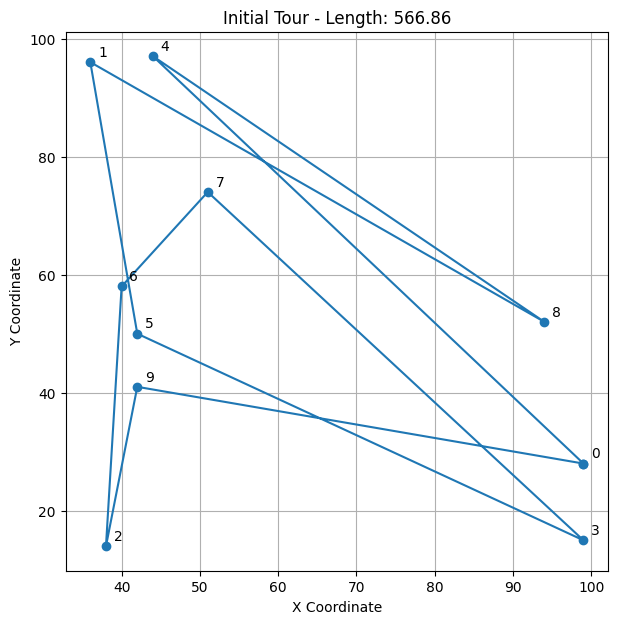

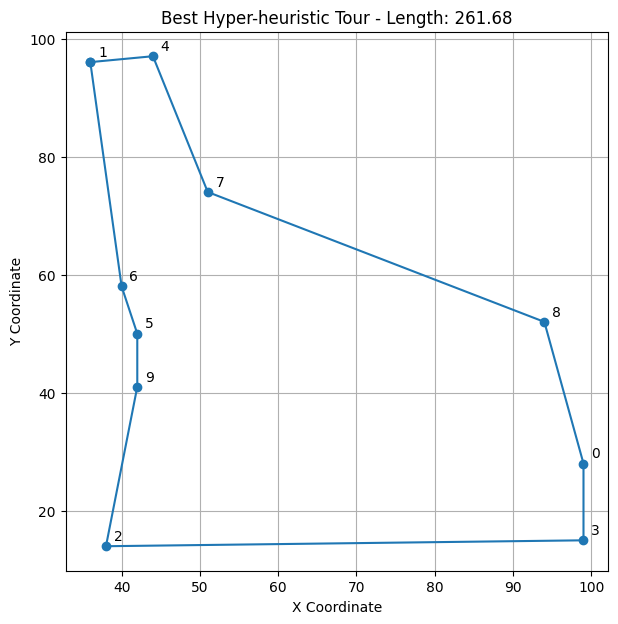

In [172]:
plot_tour(
    cities,
    initial_tour,
    title=f"Initial Tour - Length: {initial_tour_length:.2f}"
)

plot_tour(
    cities,
    hh_best_tour,
    title=f"Best Hyper-heuristic Tour - Length: {hh_best_distance:.2f}"
)

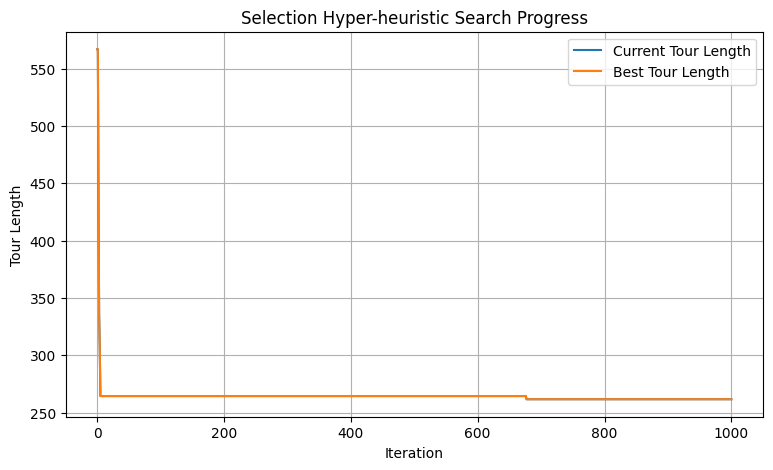

In [173]:
hh_current_history = hyper_heuristic_results[
    "current_distance_history"
]

hh_best_history = hyper_heuristic_results[
    "best_distance_history"
]

plt.figure(figsize=(9, 5))

plt.plot(
    hh_current_history,
    label="Current Tour Length"
)

plt.plot(
    hh_best_history,
    label="Best Tour Length"
)

plt.title("Selection Hyper-heuristic Search Progress")
plt.xlabel("Iteration")
plt.ylabel("Tour Length")
plt.legend()
plt.grid(True)
plt.show()

In [174]:
hh_distance_improvement = (
    initial_tour_length - hh_best_distance
)

hh_improvement_percentage = (
    hh_distance_improvement / initial_tour_length
) * 100

print(
    "Distance improvement:",
    round(hh_distance_improvement, 2)
)

print(
    "Improvement percentage:",
    round(hh_improvement_percentage, 2),
    "%"
)

Distance improvement: 305.19
Improvement percentage: 53.84 %


In [175]:
accepted_move_history = hyper_heuristic_results[
    "accepted_move_history"
]

number_of_accepted_moves = sum(
    accepted_move_history
)

acceptance_rate = (
    number_of_accepted_moves
    / len(accepted_move_history)
) * 100

print(
    "Accepted moves:",
    number_of_accepted_moves
)

print(
    "Acceptance rate:",
    round(acceptance_rate, 2),
    "%"
)

Accepted moves: 5
Acceptance rate: 0.5 %


### 7.8 Low-Level Heuristic Usage

The number of times each low-level heuristic was selected is displayed to show how the hyper-heuristic used different operators.


In [176]:
selected_heuristic_history = hyper_heuristic_results[
    "selected_heuristic_history"
]

heuristic_usage = {
    "random_swap": selected_heuristic_history.count(
        "random_swap"
    ),
    "adjacent_swap": selected_heuristic_history.count(
        "adjacent_swap"
    ),
    "insertion": selected_heuristic_history.count(
        "insertion"
    ),
    "inversion": selected_heuristic_history.count(
        "inversion"
    )
}

for heuristic_name, usage_count in heuristic_usage.items():
    print(
        heuristic_name,
        "- Selected:",
        usage_count,
        "times"
    )

random_swap - Selected: 141 times
adjacent_swap - Selected: 141 times
insertion - Selected: 142 times
inversion - Selected: 141 times


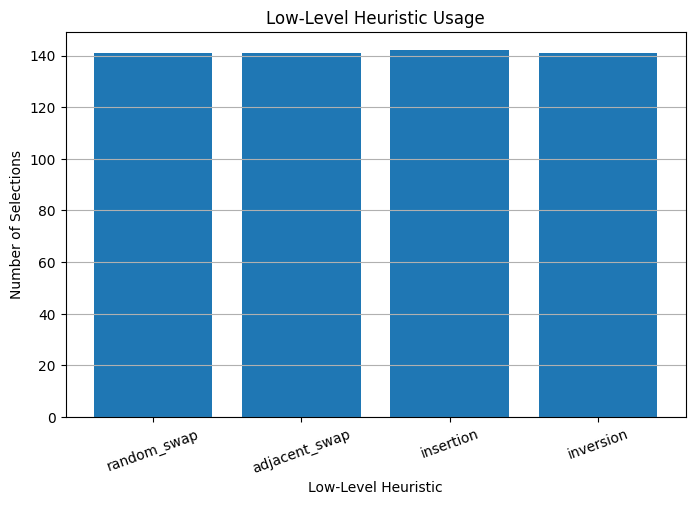

In [177]:
plt.figure(figsize=(8, 5))

plt.bar(
    heuristic_usage.keys(),
    heuristic_usage.values()
)

plt.title("Low-Level Heuristic Usage")
plt.xlabel("Low-Level Heuristic")
plt.ylabel("Number of Selections")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

When Reinforcement Learning is selected, the final score of each heuristic is displayed. These scores show the effect of the rewards and penalties given during the search.


In [178]:
if heuristic_selection_method == "reinforcement_learning":
    final_heuristic_scores = hyper_heuristic_results[
        "heuristic_scores"
    ]

    print("Final heuristic scores:")

    for heuristic_name, score in final_heuristic_scores.items():
        print(
            heuristic_name,
            "- Score:",
            round(score, 2)
        )

Final heuristic scores:
random_swap - Score: -70.5
adjacent_swap - Score: -70.5
insertion - Score: -69.5
inversion - Score: -70.5
first_improvement - Score: -70.5
best_improvement - Score: -70.5
davis_hill_climbing - Score: -70.5


In [179]:
if heuristic_selection_method == "choice_function":
    final_choice_performance = hyper_heuristic_results[
        "choice_performance"
    ]

    print("Final Choice Function performance:")

    for heuristic_name, performance in final_choice_performance.items():
        print(
            heuristic_name,
            "- Performance:",
            round(performance, 2)
        )

## 8. Frontend Result Format

The following functions convert the outputs of different algorithms into a common structure for the future web visualisation.


### 8.1 Common Result Structure
### 8.1 统一结果结构

The outputs of the four algorithms are converted into a common data structure so that the future web frontend can process them in the same way.

四种算法的输出被转换为统一的数据结构，使未来的网页前端可以用相同的方式处理结果。

In [180]:
def format_sa_results(results):
    return {
        "algorithm": "Simulated Annealing",
        "best_tour": results[0],
        "best_distance": results[1],
        "current_distance_history": results[2],
        "best_distance_history": results[3],
        "parameter_history": results[4],
        "accepted_move_history": results[5],
        "current_tour_history": results[6],
        "best_tour_history": results[7],
        "selected_heuristic_history": None,
        "parameter_name": "Temperature"
    }


def format_gd_results(results):
    return {
        "algorithm": "Great Deluge",
        "best_tour": results[0],
        "best_distance": results[1],
        "current_distance_history": results[2],
        "best_distance_history": results[3],
        "parameter_history": results[4],
        "accepted_move_history": results[5],
        "current_tour_history": results[6],
        "best_tour_history": results[7],
        "selected_heuristic_history": None,
        "parameter_name": "Water Level"
    }


def format_ils_results(results):
    return {
        "algorithm": "Iterated Local Search",
        "best_tour": results[0],
        "best_distance": results[1],
        "current_distance_history": results[2],
        "best_distance_history": results[3],
        "parameter_history": None,
        "accepted_move_history": None,
        "current_tour_history": results[4],
        "best_tour_history": results[5],
        "selected_heuristic_history": None,
        "parameter_name": None
    }


def format_hh_results(results):
    return {
        "algorithm": "Selection Hyper-heuristic",
        "best_tour": results["best_tour"],
        "best_distance": results["best_distance"],
        "current_distance_history": (
            results["current_distance_history"]
        ),
        "best_distance_history": (
            results["best_distance_history"]
        ),
        "parameter_history": None,
        "accepted_move_history": (
            results["accepted_move_history"]
        ),
        "current_tour_history": (
            results["current_tour_history"]
        ),
        "best_tour_history": (
            results["best_tour_history"]
        ),
        "selected_heuristic_history": (
            results["selected_heuristic_history"]
        ),
        "parameter_name": None
    }

### 8.2 Unified Backend Runner

This function provides one common entry point for running all four algorithms. The future web frontend only needs to specify the algorithm and its required parameters.



In [181]:
def run_algorithm_backend(
    algorithm,
    cities,
    initial_tour,
    **parameters
):
    validate_backend_inputs(
        algorithm,
        cities,
        initial_tour,
        parameters
    )

    if algorithm == "simulated_annealing":
        raw_results = simulated_annealing(
            cities=cities,
            initial_tour=initial_tour,
            **parameters
        )

        result = format_sa_results(
            raw_results
        )

    elif algorithm == "great_deluge":
        raw_results = great_deluge(
            cities=cities,
            initial_tour=initial_tour,
            **parameters
        )

        result = format_gd_results(
            raw_results
        )

    elif algorithm == "iterated_local_search":
        raw_results = iterated_local_search(
            cities=cities,
            initial_tour=initial_tour,
            **parameters
        )

        result = format_ils_results(
            raw_results
        )

    elif (
        algorithm
        == "selection_hyper_heuristic"
    ):
        raw_results = selection_hyper_heuristic(
            cities=cities,
            initial_tour=initial_tour,
            **parameters
        )

        result = format_hh_results(
            raw_results
        )

    else:
        raise ValueError(
            "Unknown algorithm."
        )

    result = make_result_json_safe(
        result
    )

    result["states"] = (
        build_frontend_states(
            result
        )
    )

    return result

### 8.3 Backend Input Validation

The following function checks the main inputs before an algorithm is executed. This helps prevent invalid values from being passed from the future web frontend.


In [182]:
def validate_backend_inputs(
    algorithm,
    cities,
    initial_tour,
    parameters
):
    valid_algorithms = [
        "simulated_annealing",
        "great_deluge",
        "iterated_local_search",
        "selection_hyper_heuristic"
    ]

    if algorithm not in valid_algorithms:
        raise ValueError(
            "Unknown algorithm."
        )

    if len(cities) < 2:
        raise ValueError(
            "At least two cities are required."
        )

    if len(initial_tour) != len(cities):
        raise ValueError(
            "The initial tour must contain all cities."
        )

    if sorted(initial_tour) != list(
        range(len(cities))
    ):
        raise ValueError(
            "The initial tour is not a valid permutation."
        )

    if "number_of_iterations" in parameters:
        if parameters["number_of_iterations"] <= 0:
            raise ValueError(
                "Number of iterations must be greater than 0."
            )

    if algorithm == "simulated_annealing":
        if parameters.get(
            "initial_temperature",
            0
        ) <= 0:
            raise ValueError(
                "Initial temperature must be greater than 0."
            )

    if algorithm == "great_deluge":
        if parameters.get(
            "water_level_ratio",
            0
        ) <= 0:
            raise ValueError(
                "Water level ratio must be greater than 0."
            )

    if algorithm == "selection_hyper_heuristic":
        available_heuristics = parameters.get(
            "available_heuristics",
            []
        )

        if len(available_heuristics) == 0:
            raise ValueError(
                "At least one low-level heuristic must be selected."
            )

### 8.4 JSON-safe Result Conversion

The following function converts the algorithm result into data types that can be safely transferred to a future web frontend.


In [183]:
def make_result_json_safe(result):
    json_safe_result = {}

    for key, value in result.items():

        if isinstance(value, tuple):
            json_safe_result[key] = list(value)

        elif isinstance(value, list):
            converted_list = []

            for item in value:
                if isinstance(item, tuple):
                    converted_list.append(
                        list(item)
                    )
                else:
                    converted_list.append(
                        item
                    )

            json_safe_result[key] = (
                converted_list
            )

        else:
            json_safe_result[key] = value

    return json_safe_result

### 8.5 Frontend State Data

The following function combines the recorded histories into iteration-by-iteration state data for the future web visualisation.


In [184]:
def build_frontend_states(result):
    states = []

    current_tour_history = result[
        "current_tour_history"
    ]

    current_distance_history = result[
        "current_distance_history"
    ]

    best_tour_history = result[
        "best_tour_history"
    ]

    best_distance_history = result[
        "best_distance_history"
    ]

    accepted_move_history = result.get(
        "accepted_move_history"
    )

    selected_heuristic_history = result.get(
        "selected_heuristic_history"
    )

    parameter_history = result.get(
        "parameter_history"
    )

    parameter_name = result.get(
        "parameter_name"
    )

    number_of_states = len(
        current_tour_history
    )

    for iteration in range(
        number_of_states
    ):
        state = {
            "iteration": iteration,
            "current_tour": (
                current_tour_history[
                    iteration
                ]
            ),
            "current_distance": (
                current_distance_history[
                    iteration
                ]
            ),
            "best_tour": (
                best_tour_history[
                    iteration
                ]
            ),
            "best_distance": (
                best_distance_history[
                    iteration
                ]
            ),
            "accepted": None,
            "selected_heuristic": None,
            "parameter_name": (
                parameter_name
            ),
            "parameter_value": None
        }

        if (
            accepted_move_history
            is not None
            and iteration > 0
        ):
            state["accepted"] = (
                accepted_move_history[
                    iteration - 1
                ]
            )

        if (
            selected_heuristic_history
            is not None
            and iteration > 0
        ):
            state[
                "selected_heuristic"
            ] = (
                selected_heuristic_history[
                    iteration - 1
                ]
            )

        if parameter_history is not None:
            if iteration < len(
                parameter_history
            ):
                state[
                    "parameter_value"
                ] = parameter_history[
                    iteration
                ]

        states.append(
            state
        )

    return states

### 8.6 Frontend Configuration Data

The following function provides the available algorithms and parameter options required by the future web frontend.


In [185]:
def get_frontend_configuration():
    return {
        "algorithms": [
            {
                "label": "Simulated Annealing",
                "value": "simulated_annealing"
            },
            {
                "label": "Great Deluge",
                "value": "great_deluge"
            },
            {
                "label": "Iterated Local Search",
                "value": "iterated_local_search"
            },
            {
                "label": "Selection Hyper-heuristic",
                "value": "selection_hyper_heuristic"
            }
        ],

        "cooling_methods": [
            {
                "label": "Geometric",
                "value": "geometric"
            },
            {
                "label": "Linear",
                "value": "linear"
            },
            {
                "label": "Lundy-Mees",
                "value": "lundy_mees"
            }
        ],

        "local_search_methods": [
            {
                "label": "First Improvement",
                "value": "first_improvement"
            },
            {
                "label": "Best Improvement",
                "value": "best_improvement"
            }
        ],

        "perturbation_methods": [
            {
                "label": "Random Swap",
                "value": "random_swap"
            },
            {
                "label": "Multiple Random Swaps",
                "value": "multiple_random_swaps"
            }
        ],

        "heuristic_selection_methods": [
            {
                "label": "Reinforcement Learning",
                "value": "reinforcement_learning"
            },
            {
                "label": "Choice Function",
                "value": "choice_function"
            }
        ],

        "move_acceptance_methods": [
            {
                "label": "Simulated Annealing",
                "value": "simulated_annealing"
            },
            {
                "label": "Great Deluge",
                "value": "great_deluge"
            },
            {
                "label": "Only Improving",
                "value": "only_improving"
            },
            {
                "label": "Improving or Equal",
                "value": "improving_or_equal"
            },
            {
                "label": "Naive Acceptance",
                "value": "naive"
            }
        ],

        "low_level_heuristics": [
            {
                "label": "Random Swap",
                "value": "random_swap"
            },
            {
                "label": "Adjacent Swap",
                "value": "adjacent_swap"
            },
            {
                "label": "Insertion",
                "value": "insertion"
            },
            {
                "label": "Inversion",
                "value": "inversion"
            },
            {
                "label": "First Improvement",
                "value": "first_improvement"
            },
            {
                "label": "Best Improvement",
                "value": "best_improvement"
            },
            {
                "label": "Davis-style",
                "value": "davis_hill_climbing"
            }
        ]
    }

### 10. Web Application

This section develops the web application that connects the TSP optimisation algorithms with an interactive visualisation interface.

#### 10.1 Basic Web Page

The basic web page allows the user to select the TSP size, optimisation algorithm, and number of iterations.

In [186]:
from flask import (
    Flask,
    request,
    jsonify,
    render_template_string
)

import threading

In [187]:
web_app = Flask(__name__)


WEB_PAGE = """
<!DOCTYPE html>

<html>

<head>

    <title>TSP Optimisation Visualisation</title>

    <style>

        body {
            font-family: Arial, sans-serif;
            background-color: #f5f5f5;
            margin: 0;
            padding: 40px;
        }

        .container {
            max-width: 800px;
            margin: auto;
            background-color: white;
            padding: 30px;
            border-radius: 10px;
        }

        h1 {
            margin-top: 0;
        }

        .control-group {
            margin-bottom: 20px;
        }

        label {
            display: block;
            margin-bottom: 6px;
            font-weight: bold;
        }

        select,
        input {
            width: 100%;
            padding: 8px;
            box-sizing: border-box;
        }

        button {
            padding: 10px 18px;
            cursor: pointer;
        }

        #result {
            display: none;
            margin-top: 25px;
            padding: 15px;
            background-color: #f0f0f0;
            border-radius: 6px;
        }

    </style>

</head>


<body>

<div class="container">

    <h1>TSP Optimisation Visualisation</h1>


    <div class="control-group">

        <label for="cities">
            Number of cities
        </label>

        <input
            id="cities"
            type="number"
            value="10"
            min="2"
            max="100"
        >

    </div>


    <div class="control-group">

        <label for="algorithm">
            Algorithm
        </label>

        <select id="algorithm">

            <option value="simulated_annealing">
                Simulated Annealing
            </option>

            <option value="great_deluge">
                Great Deluge
            </option>

            <option value="iterated_local_search">
                Iterated Local Search
            </option>

            <option value="selection_hyper_heuristic">
                Selection Hyper-heuristic
            </option>

        </select>

    </div>


    <div class="control-group">

        <label for="iterations">
            Number of iterations
        </label>

        <input
            id="iterations"
            type="number"
            value="500"
            min="1"
        >

    </div>


    <button id="runButton">
        Run Algorithm
    </button>


    <div id="result"></div>


    <!-- ROUTE_SLOT -->

</div>


<script>

document.getElementById(
    "runButton"
).addEventListener(
    "click",
    async function () {

        const numberOfCities =
            parseInt(
                document.getElementById(
                    "cities"
                ).value
            );


        const algorithm =
            document.getElementById(
                "algorithm"
            ).value;


        const iterations =
            parseInt(
                document.getElementById(
                    "iterations"
                ).value
            );


        const resultArea =
            document.getElementById(
                "result"
            );


        resultArea.style.display =
            "block";


        resultArea.innerHTML =
            "Running algorithm...";


        try {

            const response =
                await fetch(
                    "/run",
                    {

                        method: "POST",

                        headers: {
                            "Content-Type":
                                "application/json"
                        },

                        body: JSON.stringify({

                            number_of_cities:
                                numberOfCities,

                            algorithm:
                                algorithm,

                            number_of_iterations:
                                iterations

                        })

                    }
                );


            const data =
                await response.json();


            if (data.error) {

                resultArea.innerHTML =
                    "Error: "
                    + data.error;

                return;

            }


            resultArea.innerHTML =
                "<strong>Algorithm:</strong> "
                + data.algorithm
                + "<br><br>"
                + "<strong>Best distance:</strong> "
                + Number(
                    data.best_distance
                ).toFixed(2)
                + "<br><br>"
                + "<strong>Best tour:</strong> "
                + data.best_tour.join(
                    " → "
                );

        }


        catch (error) {

            resultArea.innerHTML =
                "Error: "
                + error.message;

        }

    }
);

</script>

</body>

</html>
"""


@web_app.route("/")
def web_home():

    return render_template_string(
        WEB_PAGE
    )

### 10.2 Algorithm API

The following API receives input from the web interface, runs the selected optimisation algorithm, and returns structured result data to the webpage.


In [188]:
@web_app.route(
    "/run",
    methods=["POST"]
)
def run_web_algorithm():

    try:

        input_data = request.get_json()


        number_of_cities = int(
            input_data[
                "number_of_cities"
            ]
        )


        algorithm = input_data[
            "algorithm"
        ]


        number_of_iterations = int(
            input_data[
                "number_of_iterations"
            ]
        )


        web_cities = generate_cities(
            number_of_cities
        )


        web_initial_tour = (
            create_initial_tour(
                number_of_cities
            )
        )


        if (
            algorithm
            == "simulated_annealing"
        ):

            result = run_algorithm_backend(
                algorithm=algorithm,
                cities=web_cities,
                initial_tour=web_initial_tour,
                number_of_iterations=(
                    number_of_iterations
                ),
                initial_temperature=float(
                    input_data.get(
                        "initial_temperature",
                        1000.0
                    )
                ),
                cooling_method=input_data.get(
                    "cooling_method",
                    "geometric"
                ),
                geometric_cooling_rate=float(
                    input_data.get(
                        "geometric_cooling_rate",
                        0.995
                    )
                ),
                linear_cooling_amount=float(
                    input_data.get(
                        "linear_cooling_amount",
                        1.0
                    )
                ),
                lundy_mees_beta=float(
                    input_data.get(
                        "lundy_mees_beta",
                        0.00001
                    )
                )
            )


        elif (
            algorithm
            == "great_deluge"
        ):

            result = run_algorithm_backend(
                algorithm=algorithm,
                cities=web_cities,
                initial_tour=web_initial_tour,
                number_of_iterations=(
                    number_of_iterations
                ),
                water_level_ratio=float(
                    input_data.get(
                        "water_level_ratio",
                        1.2
                    )
                ),
                water_level_reduction=float(
                    input_data.get(
                        "water_level_reduction",
                        0.3
                    )
                )
            )


        elif (
            algorithm
            == "iterated_local_search"
        ):

            result = run_algorithm_backend(
                algorithm=algorithm,
                cities=web_cities,
                initial_tour=web_initial_tour,
                number_of_iterations=(
                    number_of_iterations
                ),
                local_search_method=input_data.get(
                    "local_search_method",
                    "first_improvement"
                ),
                perturbation_method=input_data.get(
                    "perturbation_method",
                    "random_swap"
                ),
                number_of_swaps=int(
                    input_data.get(
                        "number_of_swaps",
                        2
                    )
                )
            )


        elif (
            algorithm
            == "selection_hyper_heuristic"
        ):

            result = run_algorithm_backend(
                algorithm=algorithm,
                cities=web_cities,
                initial_tour=web_initial_tour,
                number_of_iterations=(
                    number_of_iterations
                ),
                available_heuristics=input_data.get(
                    "available_heuristics",
                    [
                        "random_swap",
                        "adjacent_swap",
                        "insertion",
                        "inversion"
                    ]
                ),
                heuristic_selection_method=input_data.get(
                    "heuristic_selection_method",
                    "reinforcement_learning"
                ),
                move_acceptance_method=input_data.get(
                    "move_acceptance_method",
                    "only_improving"
                ),
                tournament_size=int(
                    input_data.get(
                        "tournament_size",
                        2
                    )
                ),
                learning_rate=float(
                    input_data.get(
                        "learning_rate",
                        1.0
                    )
                ),
                choice_performance_weight=float(
                    input_data.get(
                        "choice_performance_weight",
                        1.0
                    )
                ),
                choice_recency_weight=float(
                    input_data.get(
                        "choice_recency_weight",
                        0.1
                    )
                ),
                choice_memory_factor=float(
                    input_data.get(
                        "choice_memory_factor",
                        0.8
                    )
                ),
                initial_temperature=float(
                    input_data.get(
                        "hh_initial_temperature",
                        1000.0
                    )
                ),
                cooling_method=input_data.get(
                    "hh_cooling_method",
                    "geometric"
                ),
                geometric_cooling_rate=float(
                    input_data.get(
                        "hh_geometric_cooling_rate",
                        0.995
                    )
                ),
                linear_cooling_amount=float(
                    input_data.get(
                        "hh_linear_cooling_amount",
                        1.0
                    )
                ),
                lundy_mees_beta=float(
                    input_data.get(
                        "hh_lundy_mees_beta",
                        0.00001
                    )
                ),
                water_level_ratio=float(
                    input_data.get(
                        "hh_water_level_ratio",
                        1.2
                    )
                ),
                water_level_reduction=float(
                    input_data.get(
                        "hh_water_level_reduction",
                        0.3
                    )
                )
            )


        else:

            raise ValueError(
                "Unknown algorithm."
            )


        result["cities"] = (
            web_cities
        )


        return jsonify(
            result
        )


    except Exception as error:

        return jsonify({
            "error": str(error)
        }), 400

### 10.3 Run the Web Application

The following code starts the local web application server so that the interface can be opened in a web browser.


In [189]:
def start_web_application():

    web_app.run(
        host="127.0.0.1",
        port=5000,
        debug=False,
        use_reloader=False
    )


web_thread = threading.Thread(
    target=start_web_application,
    daemon=True
)


web_thread.start()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


### 10.4 Route Visualisation

The route visualisation displays the best TSP route returned by the selected optimisation algorithm.


In [190]:
ROUTE_CANVAS = """
<div
    id="routeSection"
    style="
        margin-top: 25px;
        display: none;
    "
>

    <canvas
        id="routeCanvas"
        width="700"
        height="500"
        style="
            width: 100%;
            border: 1px solid #cccccc;
            background-color: white;
        "
    ></canvas>

</div>
"""

In [191]:
ROUTE_SCRIPT = """
function drawRoute(cities, tour) {

    const canvas =
        document.getElementById(
            "routeCanvas"
        );

    const context =
        canvas.getContext(
            "2d"
        );

    context.clearRect(
        0,
        0,
        canvas.width,
        canvas.height
    );

    if (
        !cities
        || !tour
        || cities.length === 0
        || tour.length === 0
    ) {
        return;
    }

    const padding = 40;

    const xValues =
        cities.map(
            city => city[0]
        );

    const yValues =
        cities.map(
            city => city[1]
        );

    const minX =
        Math.min(
            ...xValues
        );

    const maxX =
        Math.max(
            ...xValues
        );

    const minY =
        Math.min(
            ...yValues
        );

    const maxY =
        Math.max(
            ...yValues
        );

    const xRange =
        Math.max(
            maxX - minX,
            1
        );

    const yRange =
        Math.max(
            maxY - minY,
            1
        );


    function transformCity(
        city
    ) {

        const x =
            padding
            + (
                (city[0] - minX)
                / xRange
            )
            * (
                canvas.width
                - 2 * padding
            );

        const y =
            canvas.height
            - padding
            - (
                (city[1] - minY)
                / yRange
            )
            * (
                canvas.height
                - 2 * padding
            );

        return [
            x,
            y
        ];
    }


    context.beginPath();


    for (
        let position = 0;
        position < tour.length;
        position++
    ) {

        const cityIndex =
            tour[
                position
            ];

        const point =
            transformCity(
                cities[
                    cityIndex
                ]
            );


        if (
            position === 0
        ) {

            context.moveTo(
                point[0],
                point[1]
            );

        }

        else {

            context.lineTo(
                point[0],
                point[1]
            );

        }
    }


    const firstPoint =
        transformCity(
            cities[
                tour[0]
            ]
        );


    context.lineTo(
        firstPoint[0],
        firstPoint[1]
    );


    context.strokeStyle =
        "#2563eb";

    context.lineWidth =
        2;

    context.stroke();


    cities.forEach(
        function(
            city,
            cityIndex
        ) {

            const point =
                transformCity(
                    city
                );


            context.beginPath();


            context.arc(
                point[0],
                point[1],
                5,
                0,
                Math.PI * 2
            );


            context.fillStyle =
                "#111827";

            context.fill();


            context.font =
                "13px Arial";


            context.fillText(
                cityIndex,
                point[0] + 8,
                point[1] - 8
            );

        }
    );
}
"""

In [192]:
SHOW_ROUTE_SCRIPT = """
function showRouteSection() {

    document.getElementById(
        "routeSection"
    ).style.display =
        "block";
}
"""


WEB_PAGE = WEB_PAGE.replace(
    "<!-- ROUTE_SLOT -->",
    ROUTE_CANVAS
)


WEB_PAGE = WEB_PAGE.replace(
    "<script>",
    "<script>\n"
    + ROUTE_SCRIPT
    + "\n"
    + SHOW_ROUTE_SCRIPT
)


WEB_PAGE = WEB_PAGE.replace(
    """
                + data.best_tour.join(
                    " → "
                );
""",
    """
                + data.best_tour.join(
                    " → "
                );


            showRouteSection();


            drawRoute(
                data.cities,
                data.best_tour
            );
"""
)

### 10.5 Iteration Playback

The iteration playback allows the user to observe how the TSP route changes during the optimisation process.


In [193]:
PLAYBACK_CONTROLS = """
<div
    id="playbackControls"
    style="
        margin-top: 15px;
        display: none;
    "
>

    <button id="playButton">
        Play
    </button>

    <button id="pauseButton">
        Pause
    </button>


    <div style="margin-top: 12px;">

        <span id="playbackStateLabel">
            Iteration
        </span>

        <span id="iterationValue">
            0
        </span>

    </div>


    <input
        id="iterationSlider"
        type="range"
        min="0"
        max="0"
        value="0"
        step="1"
        style="
            width: 100%;
            margin-top: 10px;
        "
    >

</div>
"""

In [194]:
PLAYBACK_SCRIPT = """
let currentResult = null;
let currentIteration = 0;
let playbackTimer = null;


function showIteration(
    iteration
) {

    if (!currentResult) {
        return;
    }


    const states =
        currentResult.states;


    if (
        iteration < 0
        || iteration >= states.length
    ) {
        return;
    }


    currentIteration =
        iteration;


    const state =
        states[iteration];


    drawRoute(
        currentResult.cities,
        state.current_tour
    );


    document.getElementById(
        "iterationSlider"
    ).value =
        iteration;


    document.getElementById(
        "iterationValue"
    ).textContent =
        iteration;
}


function stopPlayback() {

    if (playbackTimer !== null) {

        clearInterval(
            playbackTimer
        );

        playbackTimer =
            null;
    }
}


function startPlayback() {

    if (!currentResult) {
        return;
    }


    stopPlayback();


    if (
        currentIteration
        >= currentResult.states.length - 1
    ) {

        showIteration(
            0
        );
    }


    playbackTimer =
        setInterval(
            function () {

                if (
                    currentIteration
                    >= currentResult.states.length - 1
                ) {

                    stopPlayback();

                    return;
                }


                showIteration(
                    currentIteration + 1
                );

            },
            150
        );
}


function preparePlayback(
    data
) {

    currentResult =
        data;


    currentIteration =
        0;


    const slider =
        document.getElementById(
            "iterationSlider"
        );


    slider.min =
        0;


    slider.max =
        data.states.length - 1;


    slider.value =
        0;


    document.getElementById(
        "playbackControls"
    ).style.display =
        "block";


    showIteration(
        0
    );
}


document.getElementById(
    "playButton"
).addEventListener(
    "click",
    startPlayback
);


document.getElementById(
    "pauseButton"
).addEventListener(
    "click",
    stopPlayback
);


document.getElementById(
    "iterationSlider"
).addEventListener(
    "input",
    function () {

        stopPlayback();


        showIteration(
            parseInt(
                this.value
            )
        );
    }
);
"""

In [195]:
WEB_PAGE = WEB_PAGE.replace(
    ROUTE_CANVAS,
    ROUTE_CANVAS
    + PLAYBACK_CONTROLS
)


WEB_PAGE = WEB_PAGE.replace(
    "</script>",
    PLAYBACK_SCRIPT
    + """
</script>
""",
    1
)


WEB_PAGE = WEB_PAGE.replace(
    """
            showRouteSection();


            drawRoute(
                data.cities,
                data.best_tour
            );
""",
    """
            showRouteSection();


            preparePlayback(
                data
            );
"""
)

### 10.6 Optimisation Status

The optimisation status panel displays information about the current iteration, including current distance, best distance, move acceptance, selected heuristic, and algorithm parameter values.


In [196]:
STATUS_PANEL = """
<div
    id="statusPanel"
    style="
        margin-top: 20px;
        padding: 15px;
        background-color: #f0f0f0;
        border-radius: 6px;
        display: none;
    "
>

    <div>
        <strong>Current distance:</strong>
        <span id="currentDistance">-</span>
    </div>

    <br>

    <div>
        <strong>Best distance:</strong>
        <span id="bestDistance">-</span>
    </div>

    <br>

    <div>
        <strong>Accepted:</strong>
        <span id="acceptedValue">-</span>
    </div>

    <br>

    <div>
        <strong>Selected heuristic:</strong>
        <span id="heuristicValue">-</span>
    </div>

    <br>

    <div>
        <strong>
            <span id="parameterName">
                Parameter
            </span>:
        </strong>

        <span id="parameterValue">
            -
        </span>
    </div>

</div>
"""

In [197]:
STATUS_SCRIPT = """
function updateStatus(state) {

    document.getElementById(
        "statusPanel"
    ).style.display =
        "block";


    document.getElementById(
        "currentDistance"
    ).textContent =
        Number(
            state.current_distance
        ).toFixed(2);


    document.getElementById(
        "bestDistance"
    ).textContent =
        Number(
            state.best_distance
        ).toFixed(2);


    if (
        state.accepted === null
        || state.accepted === undefined
    ) {

        document.getElementById(
            "acceptedValue"
        ).textContent =
            "-";

    }

    else if (
        state.accepted
    ) {

        document.getElementById(
            "acceptedValue"
        ).textContent =
            "Accepted";

    }

    else {

        document.getElementById(
            "acceptedValue"
        ).textContent =
            "Rejected";

    }


    document.getElementById(
        "heuristicValue"
    ).textContent =
        state.selected_heuristic
        ?? "-";


    document.getElementById(
        "parameterName"
    ).textContent =
        state.parameter_name
        ?? "Parameter";


    if (
        state.parameter_value === null
        || state.parameter_value === undefined
    ) {

        document.getElementById(
            "parameterValue"
        ).textContent =
            "-";

    }

    else {

        document.getElementById(
            "parameterValue"
        ).textContent =
            Number(
                state.parameter_value
            ).toFixed(2);

    }

}
"""

In [198]:
WEB_PAGE = WEB_PAGE.replace(
    PLAYBACK_CONTROLS,
    PLAYBACK_CONTROLS
    + STATUS_PANEL
)


WEB_PAGE = WEB_PAGE.replace(
    "<script>",
    "<script>\n"
    + STATUS_SCRIPT
)


WEB_PAGE = WEB_PAGE.replace(
    """
    document.getElementById(
        "iterationValue"
    ).textContent =
        iteration;
}
""",
    """
    document.getElementById(
        "iterationValue"
    ).textContent =
        iteration;


    updateStatus(
        state
    );
}
"""
)

### 10.7 Algorithm Parameters

The web application allows users to configure algorithm-specific parameters before running the optimisation process.


#### 10.7.1 Simulated Annealing Parameters

The Simulated Annealing controls allow the user to configure the initial temperature and cooling method.


In [199]:
SA_PARAMETER_PANEL = """
<div
    id="saParameterPanel"
    style="
        margin-top: 20px;
        padding: 15px;
        background-color: #f7f7f7;
        border-radius: 6px;
    "
>

    <h3>
        Simulated Annealing Parameters
    </h3>


    <div class="control-group">

        <label for="saTemperature">
            Initial temperature
        </label>

        <input
            id="saTemperature"
            type="number"
            value="1000"
            min="0.01"
            step="10"
        >

    </div>


    <div class="control-group">

        <label for="saCoolingMethod">
            Cooling method
        </label>

        <select id="saCoolingMethod">

            <option value="geometric">
                Geometric
            </option>

            <option value="linear">
                Linear
            </option>

            <option value="lundy_mees">
                Lundy-Mees
            </option>

        </select>

    </div>


    <div
        id="saGeometricParameters"
        class="control-group"
    >

        <label for="saGeometricRate">
            Geometric cooling rate
        </label>

        <input
            id="saGeometricRate"
            type="number"
            value="0.995"
            step="0.001"
        >

    </div>


    <div
        id="saLinearParameters"
        class="control-group"
        style="display:none;"
    >

        <label for="saLinearAmount">
            Linear cooling amount
        </label>

        <input
            id="saLinearAmount"
            type="number"
            value="1.0"
            step="0.1"
        >

    </div>


    <div
        id="saLundyParameters"
        class="control-group"
        style="display:none;"
    >

        <label for="saLundyBeta">
            Lundy-Mees beta
        </label>

        <input
            id="saLundyBeta"
            type="number"
            value="0.00001"
            step="0.00001"
        >

    </div>

</div>
"""

In [200]:
SA_PARAMETER_SCRIPT = """
function updateSAParameters() {

    const coolingMethod =
        document.getElementById(
            "saCoolingMethod"
        ).value;


    document.getElementById(
        "saGeometricParameters"
    ).style.display =
        coolingMethod === "geometric"
        ? "block"
        : "none";


    document.getElementById(
        "saLinearParameters"
    ).style.display =
        coolingMethod === "linear"
        ? "block"
        : "none";


    document.getElementById(
        "saLundyParameters"
    ).style.display =
        coolingMethod === "lundy_mees"
        ? "block"
        : "none";
}


document.getElementById(
    "saCoolingMethod"
).addEventListener(
    "change",
    updateSAParameters
);


updateSAParameters();
"""

In [201]:
WEB_PAGE = WEB_PAGE.replace(
    """
    <button id="runButton">
        Run Algorithm
    </button>
""",
    SA_PARAMETER_PANEL
    + """
    <button id="runButton">
        Run Algorithm
    </button>
"""
)


WEB_PAGE = WEB_PAGE.replace(
    "</script>",
    SA_PARAMETER_SCRIPT
    + """
</script>
"""
)

In [202]:
WEB_PAGE = WEB_PAGE.replace(
    """
                        body: JSON.stringify({

                            number_of_cities:
                                numberOfCities,

                            algorithm:
                                algorithm,

                            number_of_iterations:
                                iterations

                        })
""",
    """
                        body: JSON.stringify({

                            number_of_cities:
                                numberOfCities,

                            algorithm:
                                algorithm,

                            number_of_iterations:
                                iterations,

                            initial_temperature:
                                parseFloat(
                                    document.getElementById(
                                        "saTemperature"
                                    ).value
                                ),

                            cooling_method:
                                document.getElementById(
                                    "saCoolingMethod"
                                ).value,

                            geometric_cooling_rate:
                                parseFloat(
                                    document.getElementById(
                                        "saGeometricRate"
                                    ).value
                                ),

                            linear_cooling_amount:
                                parseFloat(
                                    document.getElementById(
                                        "saLinearAmount"
                                    ).value
                                ),

                            lundy_mees_beta:
                                parseFloat(
                                    document.getElementById(
                                        "saLundyBeta"
                                    ).value
                                ),

                            water_level_ratio:
                                parseFloat(
                                    document.getElementById(
                                        "gdWaterRatio"
                                    ).value
                                ),

                            water_level_reduction:
                                parseFloat(
                                    document.getElementById(
                                        "gdWaterReduction"
                                    ).value
                                ),

                            local_search_method:
                                document.getElementById(
                                    "ilsLocalSearch"
                                ).value,

                            perturbation_method:
                                document.getElementById(
                                    "ilsPerturbation"
                                ).value,

                            number_of_swaps:
                                parseInt(
                                    document.getElementById(
                                        "ilsNumberOfSwaps"
                                    ).value
                                ),

                            available_heuristics:
                                Array.from(
                                    document.querySelectorAll(
                                        ".hhHeuristic:checked"
                                    )
                                ).map(
                                    checkbox =>
                                        checkbox.value
                                ),

                            heuristic_selection_method:
                                document.getElementById(
                                    "hhSelectionMethod"
                                ).value,

                            move_acceptance_method:
                                document.getElementById(
                                    "hhAcceptanceMethod"
                                ).value,

                            tournament_size:
                                parseInt(
                                    document.getElementById(
                                        "hhTournamentSize"
                                    ).value
                                ),

                            learning_rate:
                                parseFloat(
                                    document.getElementById(
                                        "hhLearningRate"
                                    ).value
                                ),

                            choice_performance_weight:
                                parseFloat(
                                    document.getElementById(
                                        "hhPerformanceWeight"
                                    ).value
                                ),

                            choice_recency_weight:
                                parseFloat(
                                    document.getElementById(
                                        "hhRecencyWeight"
                                    ).value
                                ),

                            choice_memory_factor:
                                parseFloat(
                                    document.getElementById(
                                        "hhMemoryFactor"
                                    ).value
                                ),

                            hh_initial_temperature:
                                parseFloat(
                                    document.getElementById(
                                        "hhTemperature"
                                    ).value
                                ),

                            hh_cooling_method:
                                document.getElementById(
                                    "hhCoolingMethod"
                                ).value,

                            hh_geometric_cooling_rate:
                                parseFloat(
                                    document.getElementById(
                                        "hhGeometricRate"
                                    ).value
                                ),

                            hh_linear_cooling_amount:
                                parseFloat(
                                    document.getElementById(
                                        "hhLinearAmount"
                                    ).value
                                ),

                            hh_lundy_mees_beta:
                                parseFloat(
                                    document.getElementById(
                                        "hhLundyBeta"
                                    ).value
                                ),

                            hh_water_level_ratio:
                                parseFloat(
                                    document.getElementById(
                                        "hhWaterRatio"
                                    ).value
                                ),

                            hh_water_level_reduction:
                                parseFloat(
                                    document.getElementById(
                                        "hhWaterReduction"
                                    ).value
                                )

                        })
"""
)

#### 10.7.2 Great Deluge Parameters

The Great Deluge controls allow the user to configure the initial water level ratio and water level reduction.


In [203]:
GD_PARAMETER_PANEL = """
<div
    id="gdParameterPanel"
    style="
        margin-top: 20px;
        padding: 15px;
        background-color: #f7f7f7;
        border-radius: 6px;
        display: none;
    "
>

    <h3>
        Great Deluge Parameters
    </h3>


    <div class="control-group">

        <label for="gdWaterRatio">
            Water level ratio
        </label>

        <input
            id="gdWaterRatio"
            type="number"
            value="1.2"
            step="0.1"
        >

    </div>


    <div class="control-group">

        <label for="gdWaterReduction">
            Water level reduction
        </label>

        <input
            id="gdWaterReduction"
            type="number"
            value="0.3"
            step="0.1"
        >

    </div>

</div>
"""

In [204]:
WEB_PAGE = WEB_PAGE.replace(
    SA_PARAMETER_PANEL,
    SA_PARAMETER_PANEL
    + GD_PARAMETER_PANEL
)

In [205]:
ALGORITHM_PARAMETER_SCRIPT = """
function updateAlgorithmParameterPanels() {

    const algorithm =
        document.getElementById(
            "algorithm"
        ).value;


    document.getElementById(
        "saParameterPanel"
    ).style.display =
        algorithm === "simulated_annealing"
        ? "block"
        : "none";


    document.getElementById(
        "gdParameterPanel"
    ).style.display =
        algorithm === "great_deluge"
        ? "block"
        : "none";


    document.getElementById(
        "ilsParameterPanel"
    ).style.display =
        algorithm === "iterated_local_search"
        ? "block"
        : "none";


    document.getElementById(
        "hhParameterPanel"
    ).style.display =
        algorithm === "selection_hyper_heuristic"
        ? "block"
        : "none";
}


document.getElementById(
    "algorithm"
).addEventListener(
    "change",
    updateAlgorithmParameterPanels
);


updateAlgorithmParameterPanels();
"""

In [206]:
WEB_PAGE = WEB_PAGE.replace(
    "</script>",
    ALGORITHM_PARAMETER_SCRIPT
    + """
</script>
"""
)

#### 10.7.3 Iterated Local Search Parameters

The Iterated Local Search controls allow the user to select the local search method and perturbation method.


In [207]:
ILS_PARAMETER_PANEL = """
<div
    id="ilsParameterPanel"
    style="
        margin-top: 20px;
        padding: 15px;
        background-color: #f7f7f7;
        border-radius: 6px;
        display: none;
    "
>

    <h3>
        Iterated Local Search Parameters
    </h3>


    <div class="control-group">

        <label for="ilsLocalSearch">
            Local search method
        </label>

        <select id="ilsLocalSearch">

            <option value="first_improvement">
                First Improvement
            </option>

            <option value="best_improvement">
                Best Improvement
            </option>

        </select>

    </div>


    <div class="control-group">

        <label for="ilsPerturbation">
            Perturbation method
        </label>

        <select id="ilsPerturbation">

            <option value="random_swap">
                Random Swap
            </option>

            <option value="multiple_random_swaps">
                Multiple Random Swaps
            </option>

        </select>

    </div>


    <div
        id="ilsNumberOfSwapsGroup"
        class="control-group"
        style="display:none;"
    >

        <label for="ilsNumberOfSwaps">
            Number of swaps
        </label>

        <input
            id="ilsNumberOfSwaps"
            type="number"
            value="2"
            min="1"
        >

    </div>

</div>
"""

In [208]:
ILS_PARAMETER_SCRIPT = """
function updateILSParameters() {

    const perturbationMethod =
        document.getElementById(
            "ilsPerturbation"
        ).value;


    document.getElementById(
        "ilsNumberOfSwapsGroup"
    ).style.display =
        perturbationMethod === "multiple_random_swaps"
        ? "block"
        : "none";
}


document.getElementById(
    "ilsPerturbation"
).addEventListener(
    "change",
    updateILSParameters
);


updateILSParameters();
"""

In [209]:
WEB_PAGE = WEB_PAGE.replace(
    GD_PARAMETER_PANEL,
    GD_PARAMETER_PANEL
    + ILS_PARAMETER_PANEL
)


WEB_PAGE = WEB_PAGE.replace(
    "</script>",
    ILS_PARAMETER_SCRIPT
    + """
</script>
"""
)

#### 10.7.4 Selection Hyper-heuristic Parameters

The Selection Hyper-heuristic controls allow the user to select low-level heuristics, heuristic selection methods, and move acceptance methods.


In [210]:
HH_PARAMETER_PANEL = """
<div
    id="hhParameterPanel"
    style="
        margin-top: 20px;
        padding: 15px;
        background-color: #f7f7f7;
        border-radius: 6px;
        display: none;
    "
>

    <h3>
        Selection Hyper-heuristic Parameters
    </h3>


    <div class="control-group">

        <label>
            Low-level heuristics
        </label>


        <label>
            <input
                class="hhHeuristic"
                type="checkbox"
                value="random_swap"
                checked
            >
            Random Swap
        </label>


        <label>
            <input
                class="hhHeuristic"
                type="checkbox"
                value="adjacent_swap"
                checked
            >
            Adjacent Swap
        </label>


        <label>
            <input
                class="hhHeuristic"
                type="checkbox"
                value="insertion"
                checked
            >
            Insertion
        </label>


        <label>
            <input
                class="hhHeuristic"
                type="checkbox"
                value="inversion"
                checked
            >
            Inversion
        </label>


        <label>
            <input
                class="hhHeuristic"
                type="checkbox"
                value="first_improvement"
                checked
            >
            First Improvement
        </label>


        <label>
            <input
                class="hhHeuristic"
                type="checkbox"
                value="best_improvement"
                checked
            >
            Best Improvement
        </label>


        <label>
            <input
                class="hhHeuristic"
                type="checkbox"
                value="davis_hill_climbing"
                checked
            >
            Davis-style
        </label>

    </div>


    <div class="control-group">

        <label for="hhSelectionMethod">
            Heuristic selection method
        </label>

        <select id="hhSelectionMethod">

            <option value="reinforcement_learning">
                Reinforcement Learning
            </option>

            <option value="choice_function">
                Choice Function
            </option>

        </select>

    </div>


    <div id="hhRLParameters">

        <div class="control-group">

            <label for="hhTournamentSize">
                Tournament size
            </label>

            <input
                id="hhTournamentSize"
                type="number"
                value="2"
                min="1"
            >

        </div>


        <div class="control-group">

            <label for="hhLearningRate">
                Learning rate
            </label>

            <input
                id="hhLearningRate"
                type="number"
                value="1.0"
                step="0.1"
            >

        </div>

    </div>


    <div
        id="hhChoiceParameters"
        style="display:none;"
    >

        <div class="control-group">

            <label for="hhPerformanceWeight">
                Performance weight
            </label>

            <input
                id="hhPerformanceWeight"
                type="number"
                value="1.0"
                step="0.1"
            >

        </div>


        <div class="control-group">

            <label for="hhRecencyWeight">
                Recency weight
            </label>

            <input
                id="hhRecencyWeight"
                type="number"
                value="0.1"
                step="0.1"
            >

        </div>


        <div class="control-group">

            <label for="hhMemoryFactor">
                Memory factor
            </label>

            <input
                id="hhMemoryFactor"
                type="number"
                value="0.8"
                step="0.1"
            >

        </div>

    </div>


    <div class="control-group">

        <label for="hhAcceptanceMethod">
            Move acceptance method
        </label>

        <select id="hhAcceptanceMethod">

            <option value="simulated_annealing">
                Simulated Annealing
            </option>

            <option value="great_deluge">
                Great Deluge
            </option>

            <option value="only_improving">
                Only Improving
            </option>

            <option value="improving_or_equal">
                Improving or Equal
            </option>

            <option value="naive">
                Naive
            </option>

        </select>

    </div>


    <div id="hhSAParameters">

        <div class="control-group">

            <label for="hhTemperature">
                Initial temperature
            </label>

            <input
                id="hhTemperature"
                type="number"
                value="1000"
                min="0.01"
            >

        </div>


        <div class="control-group">

            <label for="hhCoolingMethod">
                Cooling method
            </label>

            <select id="hhCoolingMethod">

                <option value="geometric">
                    Geometric
                </option>

                <option value="linear">
                    Linear
                </option>

                <option value="lundy_mees">
                    Lundy-Mees
                </option>

            </select>

        </div>


        <div class="control-group">

            <label for="hhGeometricRate">
                Geometric cooling rate
            </label>

            <input
                id="hhGeometricRate"
                type="number"
                value="0.995"
                step="0.001"
            >

        </div>


        <div class="control-group">

            <label for="hhLinearAmount">
                Linear cooling amount
            </label>

            <input
                id="hhLinearAmount"
                type="number"
                value="1.0"
                step="0.1"
            >

        </div>


        <div class="control-group">

            <label for="hhLundyBeta">
                Lundy-Mees beta
            </label>

            <input
                id="hhLundyBeta"
                type="number"
                value="0.00001"
                step="0.00001"
            >

        </div>

    </div>


    <div
        id="hhGDParameters"
        style="display:none;"
    >

        <div class="control-group">

            <label for="hhWaterRatio">
                Water level ratio
            </label>

            <input
                id="hhWaterRatio"
                type="number"
                value="1.2"
                step="0.1"
            >

        </div>


        <div class="control-group">

            <label for="hhWaterReduction">
                Water level reduction
            </label>

            <input
                id="hhWaterReduction"
                type="number"
                value="0.3"
                step="0.1"
            >

        </div>

    </div>

</div>
"""

In [211]:
HH_PARAMETER_SCRIPT = """
function updateHHSelectionParameters() {

    const selectionMethod =
        document.getElementById(
            "hhSelectionMethod"
        ).value;


    document.getElementById(
        "hhRLParameters"
    ).style.display =
        selectionMethod === "reinforcement_learning"
        ? "block"
        : "none";


    document.getElementById(
        "hhChoiceParameters"
    ).style.display =
        selectionMethod === "choice_function"
        ? "block"
        : "none";
}


function updateHHAcceptanceParameters() {

    const acceptanceMethod =
        document.getElementById(
            "hhAcceptanceMethod"
        ).value;


    document.getElementById(
        "hhSAParameters"
    ).style.display =
        acceptanceMethod === "simulated_annealing"
        ? "block"
        : "none";


    document.getElementById(
        "hhGDParameters"
    ).style.display =
        acceptanceMethod === "great_deluge"
        ? "block"
        : "none";
}


document.getElementById(
    "hhSelectionMethod"
).addEventListener(
    "change",
    updateHHSelectionParameters
);


document.getElementById(
    "hhAcceptanceMethod"
).addEventListener(
    "change",
    updateHHAcceptanceParameters
);


updateHHSelectionParameters();
updateHHAcceptanceParameters();
"""

In [212]:
WEB_PAGE = WEB_PAGE.replace(
    ILS_PARAMETER_PANEL,
    ILS_PARAMETER_PANEL
    + HH_PARAMETER_PANEL
)


WEB_PAGE = WEB_PAGE.replace(
    "</script>",
    HH_PARAMETER_SCRIPT
    + """
</script>
"""
)

### 10.8 Web Application Testing

The web application is tested by running each optimisation algorithm and checking whether the parameters, route visualisation, iteration playback, and optimisation status are displayed correctly.


In [213]:
web_test_cases = [
    (
        "simulated_annealing",
        {
            "number_of_iterations": 50,
            "initial_temperature": 1000.0,
            "cooling_method": "geometric",
            "geometric_cooling_rate": 0.995,
            "linear_cooling_amount": 1.0,
            "lundy_mees_beta": 0.00001
        }
    ),

    (
        "great_deluge",
        {
            "number_of_iterations": 50,
            "water_level_ratio": 1.2,
            "water_level_reduction": 0.3
        }
    ),

    (
        "iterated_local_search",
        {
            "number_of_iterations": 50,
            "local_search_method": "first_improvement",
            "perturbation_method": "random_swap",
            "number_of_swaps": 2
        }
    ),

    (
        "selection_hyper_heuristic",
        {
            "number_of_iterations": 50,
            "available_heuristics": [
                "random_swap",
                "adjacent_swap",
                "insertion",
                "inversion"
            ],
            "heuristic_selection_method": "reinforcement_learning",
            "move_acceptance_method": "only_improving",
            "tournament_size": 2,
            "learning_rate": 1.0,
            "choice_performance_weight": 1.0,
            "choice_recency_weight": 0.1,
            "choice_memory_factor": 0.8,
            "initial_temperature": 1000.0,
            "cooling_method": "geometric",
            "geometric_cooling_rate": 0.995,
            "linear_cooling_amount": 1.0,
            "lundy_mees_beta": 0.00001,
            "water_level_ratio": 1.2,
            "water_level_reduction": 0.3
        }
    )
]


test_cities = generate_cities(
    10
)

test_initial_tour = create_initial_tour(
    len(test_cities)
)


for algorithm, parameters in web_test_cases:

    result = run_algorithm_backend(
        algorithm=algorithm,
        cities=test_cities,
        initial_tour=test_initial_tour,
        **parameters
    )


    print(
        algorithm,
        "->",
        round(
            result["best_distance"],
            2
        ),
        "| states:",
        len(
            result["states"]
        )
    )

simulated_annealing -> 432.86 | states: 51
great_deluge -> 383.89 | states: 51
iterated_local_search -> 267.63 | states: 202
selection_hyper_heuristic -> 313.79 | states: 51


In [214]:
required_web_result_keys = [
    "algorithm",
    "best_tour",
    "best_distance",
    "current_distance_history",
    "best_distance_history",
    "current_tour_history",
    "best_tour_history",
    "states"
]


for algorithm, parameters in web_test_cases:

    result = run_algorithm_backend(
        algorithm=algorithm,
        cities=test_cities,
        initial_tour=test_initial_tour,
        **parameters
    )


    missing_keys = [
        key
        for key in required_web_result_keys
        if key not in result
    ]


    if missing_keys:

        print(
            algorithm,
            "Missing:",
            missing_keys
        )

    else:

        print(
            algorithm,
            "OK"
        )

simulated_annealing OK
great_deluge OK
iterated_local_search OK
selection_hyper_heuristic OK


In [215]:
test_cities = generate_cities(
    30
)

test_initial_tour = create_initial_tour(
    30
)


test_initial_distance = 0

for position in range(
    len(test_initial_tour)
):

    current_city = test_initial_tour[
        position
    ]

    next_city = test_initial_tour[
        (position + 1)
        % len(test_initial_tour)
    ]


    test_initial_distance += (
        calculate_distance(
            test_cities[
                current_city
            ],
            test_cities[
                next_city
            ]
        )
    )


test_result = run_algorithm_backend(
    algorithm="iterated_local_search",
    cities=test_cities,
    initial_tour=test_initial_tour,
    number_of_iterations=500,
    local_search_method="first_improvement",
    perturbation_method="multiple_random_swaps",
    number_of_swaps=2
)


print(
    "True initial distance:",
    test_initial_distance
)

print(
    "Frontend state 0 distance:",
    test_result[
        "states"
    ][0][
        "current_distance"
    ]
)

print(
    "Best distance:",
    test_result[
        "best_distance"
    ]
)

True initial distance: 1812.9477991590381
Frontend state 0 distance: 1812.9477991590381
Best distance: 467.96706542928314


### 10.9 Interface Refinement

The web interface is refined to improve the organisation and readability of the controls, visualisation, and optimisation information.


In [216]:
INTERFACE_STYLE = """
<style>

    body {
        background-color: #f4f6f8;
    }

    .container {
        max-width: 1200px;
    }

    .web-layout {
        display: grid;
        grid-template-columns: 340px 1fr;
        gap: 30px;
        align-items: start;
    }

    .control-panel {
        padding: 20px;
        background-color: #f8f9fa;
        border-radius: 8px;
    }

    .visualisation-panel {
        padding: 20px;
        background-color: #ffffff;
        border: 1px solid #dddddd;
        border-radius: 8px;
    }

    button {
        border: none;
        border-radius: 5px;
        background-color: #2563eb;
        color: white;
    }

    button:hover {
        opacity: 0.9;
    }

    input,
    select {
        border: 1px solid #cccccc;
        border-radius: 4px;
    }

    #routeCanvas {
        max-width: 100%;
    }

    #statusPanel {
        line-height: 1.5;
    }

</style>
"""

In [217]:
WEB_PAGE = WEB_PAGE.replace(
    "</head>",
    INTERFACE_STYLE
    + """
</head>
"""
)

### 10.10 Input Validation

Input validation is added to prevent invalid parameter values from being submitted to the optimisation algorithms.


In [218]:
INPUT_VALIDATION_SCRIPT = """
function validateInputs() {

    const algorithm =
        document.getElementById(
            "algorithm"
        ).value;


    const numberOfCities =
        parseInt(
            document.getElementById(
                "cities"
            ).value
        );


    const iterations =
        parseInt(
            document.getElementById(
                "iterations"
            ).value
        );


    if (
        Number.isNaN(numberOfCities)
        || numberOfCities < 2
    ) {

        return "Number of cities must be at least 2.";
    }


    if (
        Number.isNaN(iterations)
        || iterations < 1
    ) {

        return "Number of iterations must be greater than 0.";
    }


    if (
        algorithm ===
        "simulated_annealing"
    ) {

        const temperature =
            parseFloat(
                document.getElementById(
                    "saTemperature"
                ).value
            );


        if (
            Number.isNaN(temperature)
            || temperature <= 0
        ) {

            return "Initial temperature must be greater than 0.";
        }


        const coolingMethod =
            document.getElementById(
                "saCoolingMethod"
            ).value;


        if (
            coolingMethod ===
            "geometric"
        ) {

            const rate =
                parseFloat(
                    document.getElementById(
                        "saGeometricRate"
                    ).value
                );


            if (
                Number.isNaN(rate)
                || rate <= 0
                || rate >= 1
            ) {

                return "Geometric cooling rate must be between 0 and 1.";
            }

        }


        if (
            coolingMethod ===
            "linear"
        ) {

            const amount =
                parseFloat(
                    document.getElementById(
                        "saLinearAmount"
                    ).value
                );


            if (
                Number.isNaN(amount)
                || amount <= 0
            ) {

                return "Linear cooling amount must be greater than 0.";
            }

        }


        if (
            coolingMethod ===
            "lundy_mees"
        ) {

            const beta =
                parseFloat(
                    document.getElementById(
                        "saLundyBeta"
                    ).value
                );


            if (
                Number.isNaN(beta)
                || beta <= 0
            ) {

                return "Lundy-Mees beta must be greater than 0.";
            }

        }

    }


    if (
        algorithm ===
        "great_deluge"
    ) {

        const waterRatio =
            parseFloat(
                document.getElementById(
                    "gdWaterRatio"
                ).value
            );


        const waterReduction =
            parseFloat(
                document.getElementById(
                    "gdWaterReduction"
                ).value
            );


        if (
            Number.isNaN(waterRatio)
            || waterRatio <= 0
        ) {

            return "Water level ratio must be greater than 0.";
        }


        if (
            Number.isNaN(waterReduction)
            || waterReduction <= 0
        ) {

            return "Water level reduction must be greater than 0.";
        }

    }


    if (
        algorithm ===
        "iterated_local_search"
    ) {

        const perturbationMethod =
            document.getElementById(
                "ilsPerturbation"
            ).value;


        if (
            perturbationMethod ===
            "multiple_random_swaps"
        ) {

            const numberOfSwaps =
                parseInt(
                    document.getElementById(
                        "ilsNumberOfSwaps"
                    ).value
                );


            if (
                Number.isNaN(numberOfSwaps)
                || numberOfSwaps < 1
            ) {

                return "Number of swaps must be at least 1.";
            }

        }

    }


    if (
        algorithm ===
        "selection_hyper_heuristic"
    ) {

        const selectedHeuristics =
            document.querySelectorAll(
                ".hhHeuristic:checked"
            );


        if (
            selectedHeuristics.length === 0
        ) {

            return "Select at least one low-level heuristic.";
        }


        const selectionMethod =
            document.getElementById(
                "hhSelectionMethod"
            ).value;


        if (
            selectionMethod ===
            "reinforcement_learning"
        ) {

            const tournamentSize =
                parseInt(
                    document.getElementById(
                        "hhTournamentSize"
                    ).value
                );


            const learningRate =
                parseFloat(
                    document.getElementById(
                        "hhLearningRate"
                    ).value
                );


            if (
                Number.isNaN(tournamentSize)
                || tournamentSize < 1
            ) {

                return "Tournament size must be at least 1.";
            }


            if (
                tournamentSize >
                selectedHeuristics.length
            ) {

                return "Tournament size cannot exceed the number of selected heuristics.";
            }


            if (
                Number.isNaN(learningRate)
                || learningRate <= 0
            ) {

                return "Learning rate must be greater than 0.";
            }

        }


        const acceptanceMethod =
            document.getElementById(
                "hhAcceptanceMethod"
            ).value;


        if (
            acceptanceMethod ===
            "simulated_annealing"
        ) {

            const temperature =
                parseFloat(
                    document.getElementById(
                        "hhTemperature"
                    ).value
                );


            if (
                Number.isNaN(temperature)
                || temperature <= 0
            ) {

                return "HH initial temperature must be greater than 0.";
            }

        }


        if (
            acceptanceMethod ===
            "great_deluge"
        ) {

            const waterRatio =
                parseFloat(
                    document.getElementById(
                        "hhWaterRatio"
                    ).value
                );


            const waterReduction =
                parseFloat(
                    document.getElementById(
                        "hhWaterReduction"
                    ).value
                );


            if (
                Number.isNaN(waterRatio)
                || waterRatio <= 0
            ) {

                return "HH water level ratio must be greater than 0.";
            }


            if (
                Number.isNaN(waterReduction)
                || waterReduction <= 0
            ) {

                return "HH water level reduction must be greater than 0.";
            }

        }

    }


    return null;
}


document.getElementById(
    "runButton"
).addEventListener(
    "click",
    function(event) {

        const validationError =
            validateInputs();


        if (
            validationError !== null
        ) {

            event.preventDefault();

            event.stopImmediatePropagation();


            document.getElementById(
                "result"
            ).innerHTML =
                "<strong>Input Error:</strong> "
                + validationError;

        }

    },
    true
);
"""

In [219]:
WEB_PAGE = WEB_PAGE.replace(
    "</script>",
    INPUT_VALIDATION_SCRIPT
    + """
</script>
"""
)

### 10.11 Run State and Error Handling

The web interface manages the running state of the optimisation process and provides clear feedback when an error occurs.


In [220]:
RUN_STATE_SCRIPT = """
const runButton =
    document.getElementById(
        "runButton"
    );


function setRunningState(
    isRunning
) {

    runButton.disabled =
        isRunning;


    if (isRunning) {

        runButton.textContent =
            "Running...";

    }

    else {

        runButton.textContent =
            "Run Algorithm";

    }
}


function showWebError(
    message
) {

    document.getElementById(
        "result"
    ).innerHTML =
        "<strong>Error:</strong> "
        + message;
}
"""

In [221]:
WEB_PAGE = WEB_PAGE.replace(
    "</script>",
    RUN_STATE_SCRIPT
    + """
</script>
"""
)

In [222]:
RUN_HANDLER_SCRIPT = """
document.getElementById(
    "runButton"
).addEventListener(
    "click",
    function() {

        setRunningState(
            true
        );

    },
    true
);


document.addEventListener(
    "DOMContentLoaded",
    function() {

        setRunningState(
            false
        );

    }
);
"""

In [223]:
WEB_PAGE = WEB_PAGE.replace(
    "</script>",
    RUN_HANDLER_SCRIPT
    + """
</script>
"""
)

In [224]:
WEB_PAGE = WEB_PAGE.replace(
    """
        catch (error) {

            resultArea.innerHTML =
                "Error: "
                + error.message;

        }

    }
);
""",
    """
        catch (error) {

            showWebError(
                error.message
            );

        }

        finally {

            setRunningState(
                false
            );

        }

    }
);
"""
)

### 10.12 Web Application Final Assembly

The web application components are combined into the final webpage after all interface functions have been defined.


In [225]:
required_web_components = [
    "WEB_PAGE",
    "ROUTE_CANVAS",
    "ROUTE_SCRIPT",
    "PLAYBACK_CONTROLS",
    "PLAYBACK_SCRIPT",
    "STATUS_PANEL",
    "STATUS_SCRIPT",
    "SA_PARAMETER_PANEL",
    "GD_PARAMETER_PANEL",
    "ILS_PARAMETER_PANEL",
    "HH_PARAMETER_PANEL",
    "INPUT_VALIDATION_SCRIPT",
    "RUN_STATE_SCRIPT"
]


missing_components = [
    component
    for component in required_web_components
    if component not in globals()
]


if missing_components:

    print(
        "Missing web components:",
        missing_components
    )

else:

    print(
        "All web application components are available."
    )

All web application components are available.


In [226]:
web_page_checks = {
    "Run button":
        'id="runButton"' in WEB_PAGE,

    "Route canvas":
        'id="routeCanvas"' in WEB_PAGE,

    "Iteration slider":
        'id="iterationSlider"' in WEB_PAGE,

    "Status panel":
        'id="statusPanel"' in WEB_PAGE,

    "SA parameters":
        'id="saParameterPanel"' in WEB_PAGE,

    "GD parameters":
        'id="gdParameterPanel"' in WEB_PAGE,

    "ILS parameters":
        'id="ilsParameterPanel"' in WEB_PAGE,

    "HH parameters":
        'id="hhParameterPanel"' in WEB_PAGE,

    "Route function":
        "function drawRoute" in WEB_PAGE,

    "Playback function":
        "function showIteration" in WEB_PAGE,

    "Input validation":
        "function validateInputs" in WEB_PAGE,

    "Running state":
        "function setRunningState" in WEB_PAGE
}


for component, available in web_page_checks.items():

    if available:

        print(
            component,
            "OK"
        )

    else:

        print(
            component,
            "MISSING"
        )

Run button OK
Route canvas OK
Iteration slider OK
Status panel OK
SA parameters OK
GD parameters OK
ILS parameters OK
HH parameters OK
Route function OK
Playback function OK
Input validation OK
Running state OK


### 10.13 Final System Test

The final system test checks whether the web API can successfully run all four optimisation algorithms and return the required visualisation data.


In [227]:
final_web_test_cases = [
    {
        "number_of_cities": 10,
        "algorithm": "simulated_annealing",
        "number_of_iterations": 50,
        "initial_temperature": 1000.0,
        "cooling_method": "geometric",
        "geometric_cooling_rate": 0.995,
        "linear_cooling_amount": 1.0,
        "lundy_mees_beta": 0.00001
    },

    {
        "number_of_cities": 10,
        "algorithm": "great_deluge",
        "number_of_iterations": 50,
        "water_level_ratio": 1.2,
        "water_level_reduction": 0.3
    },

    {
        "number_of_cities": 10,
        "algorithm": "iterated_local_search",
        "number_of_iterations": 50,
        "local_search_method": "first_improvement",
        "perturbation_method": "random_swap",
        "number_of_swaps": 2
    },

    {
        "number_of_cities": 10,
        "algorithm": "selection_hyper_heuristic",
        "number_of_iterations": 50,

        "available_heuristics": [
            "random_swap",
            "adjacent_swap",
            "insertion",
            "inversion",
            "first_improvement",
            "best_improvement",
            "davis_hill_climbing"
        ],

        "heuristic_selection_method":
            "reinforcement_learning",

        "move_acceptance_method":
            "only_improving",

        "tournament_size": 2,
        "learning_rate": 1.0,

        "choice_performance_weight": 1.0,
        "choice_recency_weight": 0.1,
        "choice_memory_factor": 0.8,

        "hh_initial_temperature": 1000.0,
        "hh_cooling_method": "geometric",
        "hh_geometric_cooling_rate": 0.995,
        "hh_linear_cooling_amount": 1.0,
        "hh_lundy_mees_beta": 0.00001,

        "hh_water_level_ratio": 1.2,
        "hh_water_level_reduction": 0.3
    }
]

In [228]:
required_web_keys = [
    "algorithm",
    "best_tour",
    "best_distance",
    "cities",
    "states"
]


with web_app.test_client() as test_client:

    for test_case in final_web_test_cases:

        response = test_client.post(
            "/run",
            json=test_case
        )


        data = response.get_json()


        algorithm = test_case[
            "algorithm"
        ]


        if response.status_code != 200:

            print(
                algorithm,
                "FAILED:",
                data
            )

            continue


        missing_keys = [
            key
            for key in required_web_keys
            if key not in data
        ]


        if missing_keys:

            print(
                algorithm,
                "FAILED - missing:",
                missing_keys
            )

            continue


        if len(data["states"]) == 0:

            print(
                algorithm,
                "FAILED - no states"
            )

            continue


        print(
            algorithm,
            "OK",
            "| best distance:",
            round(
                data["best_distance"],
                2
            ),
            "| states:",
            len(
                data["states"]
            )
        )

simulated_annealing OK | best distance: 437.33 | states: 51
great_deluge OK | best distance: 507.45 | states: 51
iterated_local_search OK | best distance: 317.62 | states: 196
selection_hyper_heuristic OK | best distance: 239.01 | states: 51


In [229]:
with web_app.test_client() as test_client:

    response = test_client.get("/")


    if response.status_code == 200:

        page_content = response.get_data(
            as_text=True
        )


        required_page_elements = [
            "TSP Optimisation Visualisation",
            "runButton",
            "routeCanvas",
            "iterationSlider",
            "statusPanel",
            "saParameterPanel",
            "gdParameterPanel",
            "ilsParameterPanel",
            "hhParameterPanel"
        ]


        missing_elements = [
            element
            for element in required_page_elements
            if element not in page_content
        ]


        if missing_elements:

            print(
                "Web page missing:",
                missing_elements
            )

        else:

            print(
                "Final web page OK"
            )


    else:

        print(
            "Web page FAILED:",
            response.status_code
        )

Final web page OK


## 8. Interactive User Interface

The interface allows the user to select an algorithm, change its parameters and run the search without editing the algorithm code.


In [230]:
import ipywidgets as widgets
from IPython.display import display, clear_output

### 8.1 Interface Controls

The interface provides general controls and algorithm-specific parameter controls.


The first controls are shared by all algorithms. The user selects an algorithm from the dropdown menu and chooses the number of search iterations.


In [231]:
widget_style = {
    "description_width": "160px"
}

algorithm_dropdown = widgets.Dropdown(
    options=[
        ("Select an algorithm", ""),
        ("Simulated Annealing", "simulated_annealing"),
        ("Great Deluge", "great_deluge"),
        ("Iterated Local Search", "iterated_local_search"),
        (
            "Selection Hyper-heuristic",
            "selection_hyper_heuristic"
        )
    ],
    value="",
    description="Algorithm:",
    style=widget_style
)

iterations_input = widgets.IntSlider(
    value=1000,
    min=100,
    max=5000,
    step=100,
    description="Iterations:",
    style=widget_style
)

In [232]:
number_of_cities_input = widgets.IntSlider(
    value=10,
    min=5,
    max=100,
    step=5,
    description="Number of cities:",
    style=widget_style
)

generate_tsp_button = widgets.Button(
    description="Generate New TSP",
    button_style="info",
    icon="refresh"
)

The following controls are used for Simulated Annealing. They allow the user to set the initial temperature, cooling method and the parameter required by each cooling method.


In [233]:
temperature_input = widgets.FloatText(
    value=1000.0,
    description="Initial temperature:",
    style=widget_style
)

cooling_dropdown = widgets.Dropdown(
    options=[
        ("Geometric", "geometric"),
        ("Linear", "linear"),
        ("Lundy-Mees", "lundy_mees")
    ],
    value="geometric",
    description="Cooling method:",
    style=widget_style
)

geometric_rate_input = widgets.FloatText(
    value=0.995,
    description="Geometric rate:",
    style=widget_style
)

linear_amount_input = widgets.FloatText(
    value=1.0,
    description="Linear amount:",
    style=widget_style
)

lundy_beta_input = widgets.FloatText(
    value=0.00001,
    description="Lundy-Mees beta:",
    style=widget_style
)

The Great Deluge controls set the starting water level ratio and the amount by which the water level is reduced after each iteration.


In [234]:
water_ratio_input = widgets.FloatText(
    value=1.2,
    description="Water level ratio:",
    style=widget_style
)

water_reduction_input = widgets.FloatText(
    value=0.3,
    description="Water reduction:",
    style=widget_style
)

The Iterated Local Search controls allow the user to choose the local search method and perturbation method. The number of swaps is only needed when Multiple Random Swaps is selected.


In [235]:
local_search_dropdown = widgets.Dropdown(
    options=[
        ("First Improvement", "first_improvement"),
        ("Best Improvement", "best_improvement")
    ],
    value="first_improvement",
    description="Local search:",
    style=widget_style
)

perturbation_dropdown = widgets.Dropdown(
    options=[
        ("Random Swap", "random_swap"),
        (
            "Multiple Random Swaps",
            "multiple_random_swaps"
        )
    ],
    value="random_swap",
    description="Perturbation:",
    style=widget_style
)

number_of_swaps_input = widgets.IntSlider(
    value=3,
    min=1,
    max=10,
    step=1,
    description="Number of swaps:",
    style=widget_style
)

In [236]:
low_level_checkboxes = {
    "random_swap": widgets.Checkbox(
        value=True,
        description="Random Swap"
    ),
    "adjacent_swap": widgets.Checkbox(
        value=True,
        description="Adjacent Swap"
    ),
    "insertion": widgets.Checkbox(
        value=True,
        description="Insertion"
    ),
    "inversion": widgets.Checkbox(
        value=True,
        description="Inversion"
    ),
    "first_improvement": widgets.Checkbox(
        value=False,
        description="First Improvement"
    ),
    "best_improvement": widgets.Checkbox(
        value=False,
        description="Best Improvement"
    ),
    "davis_hill_climbing": widgets.Checkbox(
        value=False,
        description="Davis-style"
    )
}


low_level_button = widgets.Button(
    description="Select heuristics ▼",
    layout=widgets.Layout(
        width="180px"
    )
)


low_level_done_button = widgets.Button(
    description="Done",
    button_style="info",
    layout=widgets.Layout(
        width="80px"
    )
)


low_level_options_box = widgets.VBox(
    list(low_level_checkboxes.values())
    + [low_level_done_button],
    layout=widgets.Layout(
        display="none",
        margin="5px 0px 5px 170px"
    )
)


low_level_control = widgets.VBox([
    widgets.HBox([
        widgets.HTML(
            value=(
                "<div style='width:160px;"
                "text-align:right;"
                "padding-top:6px;'>"
                "Low-level heuristics:"
                "</div>"
            )
        ),
        low_level_button
    ]),
    low_level_options_box
])


def toggle_low_level_options(button):
    if low_level_options_box.layout.display == "none":
        low_level_options_box.layout.display = "flex"
        low_level_button.description = "Select heuristics ▲"
    else:
        low_level_options_box.layout.display = "none"
        low_level_button.description = "Select heuristics ▼"


def close_low_level_options(button):
    low_level_options_box.layout.display = "none"
    low_level_button.description = "Select heuristics ▼"


low_level_button.on_click(
    toggle_low_level_options
)

low_level_done_button.on_click(
    close_low_level_options
)

The Selection Hyper-heuristic controls allow the user to choose the heuristic selection method and move acceptance method. Additional parameters are displayed later depending on these choices.


In [237]:
low_level_heuristic_dropdown = widgets.Dropdown(
    options=[
        ("Random Swap", "random_swap"),
        ("Adjacent Swap", "adjacent_swap"),
        ("Insertion", "insertion"),
        ("Inversion", "inversion"),
        ("First Improvement", "first_improvement"),
        ("Best Improvement", "best_improvement"),
        ("Davis-style", "davis_hill_climbing")
    ],
    value="random_swap",
    description="Low-level heuristic:",
    style=widget_style
)

In [238]:
selection_method_dropdown = widgets.Dropdown(
    options=[
        (
            "Reinforcement Learning",
            "reinforcement_learning"
        ),
        ("Choice Function", "choice_function")
    ],
    value="reinforcement_learning",
    description="Heuristic selection:",
    style=widget_style
)

acceptance_method_dropdown = widgets.Dropdown(
    options=[
        ("Simulated Annealing", "simulated_annealing"),
        ("Great Deluge", "great_deluge"),
        ("Only Improving", "only_improving"),
        (
            "Improving or Equal",
            "improving_or_equal"
        ),
        ("Naive Acceptance", "naive")
    ],
    value="only_improving",
    description="Move acceptance:",
    style=widget_style
)

tournament_size_input = widgets.IntSlider(
    value=2,
    min=2,
    max=4,
    step=1,
    description="Tournament size:",
    style=widget_style
)

learning_rate_input = widgets.FloatText(
    value=1.0,
    description="Learning rate:",
    style=widget_style
)

In [239]:
run_button = widgets.Button(
    description="Run Algorithm",
    button_style="success",
    icon="play",
    disabled=True
)

output_area = widgets.Output()

### 8.2 Dynamic Parameter Display

The interface only displays parameters related to the selected algorithm and method.


In [240]:
choice_performance_weight_input = widgets.FloatText(
    value=1.0,
    description="Performance weight:",
    style=widget_style
)

choice_recency_weight_input = widgets.FloatText(
    value=0.1,
    description="Recency weight:",
    style=widget_style
)

choice_memory_factor_input = widgets.FloatText(
    value=0.8,
    description="Memory factor:",
    style=widget_style
)


hh_temperature_input = widgets.FloatText(
    value=1000.0,
    description="Initial temperature:",
    style=widget_style
)

hh_cooling_dropdown = widgets.Dropdown(
    options=[
        ("Geometric", "geometric"),
        ("Linear", "linear"),
        ("Lundy-Mees", "lundy_mees")
    ],
    value="geometric",
    description="Cooling method:",
    style=widget_style
)

hh_geometric_rate_input = widgets.FloatText(
    value=0.995,
    description="Geometric rate:",
    style=widget_style
)

hh_linear_amount_input = widgets.FloatText(
    value=1.0,
    description="Linear amount:",
    style=widget_style
)

hh_lundy_beta_input = widgets.FloatText(
    value=0.00001,
    description="Lundy-Mees beta:",
    style=widget_style
)

hh_water_ratio_input = widgets.FloatText(
    value=1.2,
    description="Water level ratio:",
    style=widget_style
)

hh_water_reduction_input = widgets.FloatText(
    value=0.3,
    description="Water reduction:",
    style=widget_style
)

In [241]:
cooling_parameter_area = widgets.VBox()

ils_perturbation_parameter_area = widgets.VBox()

selection_parameter_area = widgets.VBox()

hh_cooling_parameter_area = widgets.VBox()

hh_acceptance_parameter_area = widgets.VBox()

parameter_area = widgets.VBox()

This function changes the displayed Simulated Annealing cooling parameter. Only the parameter related to the selected cooling method is shown.


In [242]:
def update_cooling_parameters(change=None):
    selected_method = cooling_dropdown.value

    if selected_method == "geometric":
        cooling_parameter_area.children = (
            geometric_rate_input,
        )

    elif selected_method == "linear":
        cooling_parameter_area.children = (
            linear_amount_input,
        )

    elif selected_method == "lundy_mees":
        cooling_parameter_area.children = (
            lundy_beta_input,
        )

This function controls whether the number-of-swaps setting is displayed. The setting is hidden for a single Random Swap and shown for Multiple Random Swaps.


In [243]:
def update_ils_perturbation_parameters(change=None):
    selected_method = perturbation_dropdown.value

    if selected_method == "random_swap":
        ils_perturbation_parameter_area.children = ()

    elif selected_method == "multiple_random_swaps":
        ils_perturbation_parameter_area.children = (
            number_of_swaps_input,
        )

This function switches between the Reinforcement Learning controls and the Choice Function controls.


In [244]:
def update_selection_parameters(change=None):
    selected_method = selection_method_dropdown.value

    if selected_method == "reinforcement_learning":
        selection_parameter_area.children = (
            tournament_size_input,
            learning_rate_input
        )

    elif selected_method == "choice_function":
        selection_parameter_area.children = (
            choice_performance_weight_input,
            choice_recency_weight_input,
            choice_memory_factor_input
        )

When Simulated Annealing is used as the Hyper-heuristic move acceptance method, this function displays the parameter required by the selected cooling method.



In [245]:
def update_hh_cooling_parameters(change=None):
    selected_method = hh_cooling_dropdown.value

    if selected_method == "geometric":
        hh_cooling_parameter_area.children = (
            hh_geometric_rate_input,
        )

    elif selected_method == "linear":
        hh_cooling_parameter_area.children = (
            hh_linear_amount_input,
        )

    elif selected_method == "lundy_mees":
        hh_cooling_parameter_area.children = (
            hh_lundy_beta_input,
        )

This function displays the extra parameters required by the selected move acceptance method. Simulated Annealing uses temperature and cooling controls, while Great Deluge uses water level controls.


In [246]:
def update_hh_acceptance_parameters(change=None):
    selected_method = acceptance_method_dropdown.value

    if selected_method == "simulated_annealing":
        hh_acceptance_parameter_area.children = (
            hh_temperature_input,
            hh_cooling_dropdown,
            hh_cooling_parameter_area
        )

    elif selected_method == "great_deluge":
        hh_acceptance_parameter_area.children = (
            hh_water_ratio_input,
            hh_water_reduction_input
        )

    else:
        hh_acceptance_parameter_area.children = ()

In [247]:
sa_parameter_box = widgets.VBox([
    widgets.HTML(
        "<b>Simulated Annealing Parameters</b>"
    ),
    temperature_input,
    cooling_dropdown,
    cooling_parameter_area
])


great_deluge_parameter_box = widgets.VBox([
    widgets.HTML(
        "<b>Great Deluge Parameters</b>"
    ),
    water_ratio_input,
    water_reduction_input
])


ils_parameter_box = widgets.VBox([
    widgets.HTML(
        "<b>Iterated Local Search Parameters</b>"
    ),
    local_search_dropdown,
    perturbation_dropdown,
    ils_perturbation_parameter_area
])


hyper_heuristic_parameter_box = widgets.VBox([
    widgets.HTML(
        "<b>Selection Hyper-heuristic Parameters</b>"
    ),
    low_level_heuristic_dropdown,
    selection_method_dropdown,
    selection_parameter_area,
    acceptance_method_dropdown,
    hh_acceptance_parameter_area
])

This function updates the main parameter area when the selected algorithm changes. It also enables the Run Algorithm button after a valid algorithm has been selected.


In [248]:
def update_algorithm_parameters(change=None):
    selected_algorithm = algorithm_dropdown.value

    if selected_algorithm == "":
        parameter_area.children = ()
        run_button.disabled = True

    elif selected_algorithm == "simulated_annealing":
        parameter_area.children = (
            sa_parameter_box,
        )
        run_button.disabled = False

    elif selected_algorithm == "great_deluge":
        parameter_area.children = (
            great_deluge_parameter_box,
        )
        run_button.disabled = False

    elif selected_algorithm == "iterated_local_search":
        parameter_area.children = (
            ils_parameter_box,
        )
        run_button.disabled = False

    elif selected_algorithm == "selection_hyper_heuristic":
        parameter_area.children = (
            hyper_heuristic_parameter_box,
        )
        run_button.disabled = False

### 8.3 Interface Assembly and Event Handling

The interface updates automatically when the user changes an algorithm or parameter option.


In [249]:
algorithm_dropdown.observe(
    update_algorithm_parameters,
    names="value"
)

cooling_dropdown.observe(
    update_cooling_parameters,
    names="value"
)

perturbation_dropdown.observe(
    update_ils_perturbation_parameters,
    names="value"
)

selection_method_dropdown.observe(
    update_selection_parameters,
    names="value"
)

acceptance_method_dropdown.observe(
    update_hh_acceptance_parameters,
    names="value"
)

hh_cooling_dropdown.observe(
    update_hh_cooling_parameters,
    names="value"
)

In [250]:
update_cooling_parameters()
update_ils_perturbation_parameters()
update_selection_parameters()
update_hh_cooling_parameters()
update_hh_acceptance_parameters()
update_algorithm_parameters()

In [251]:
interface_controls = widgets.VBox([
    widgets.HTML(
        "<h3>TSP Algorithm Configuration</h3>"
    ),

    widgets.HTML(
        "<b>TSP Instance</b>"
    ),

    number_of_cities_input,
    generate_tsp_button,

    widgets.HTML(
        "<b>Algorithm</b>"
    ),

    algorithm_dropdown,
    iterations_input,
    parameter_area,
    run_button
])

In [252]:
display(
    interface_controls,
    output_area
)

Output()

### 8.4 Run Selected Algorithm

The Run Algorithm button reads the current interface values, runs the selected algorithm and displays its results.


The following function provides one common result format for all algorithms. It calculates the improvement, prints the main values, plots the best tour and displays the current and best distance histories.


In [253]:
def display_search_results(
    algorithm_name,
    best_tour,
    best_distance,
    current_history,
    best_history
):
    starting_distance = calculate_tour_length(
        initial_tour,
        cities
    )

    improvement = starting_distance - best_distance

    improvement_percentage = (
        improvement / starting_distance
    ) * 100

    print("Algorithm:", algorithm_name)
    print(
        "Initial tour length:",
        round(starting_distance, 2)
    )
    print(
        "Best tour length:",
        round(best_distance, 2)
    )
    print(
        "Improvement:",
        round(improvement, 2)
    )
    print(
        "Improvement percentage:",
        round(improvement_percentage, 2),
        "%"
    )
    print("Best tour:", best_tour)

    plot_tour(
        cities,
        best_tour,
        title=(
            f"{algorithm_name} Best Tour "
            f"- Length: {best_distance:.2f}"
        )
    )

    plt.figure(figsize=(9, 5))

    plt.plot(
        current_history,
        label="Current Tour Length"
    )

    plt.plot(
        best_history,
        label="Best Tour Length"
    )

    plt.title(f"{algorithm_name} Search Progress")
    plt.xlabel("Iteration")
    plt.ylabel("Tour Length")
    plt.legend()
    plt.grid(True)
    plt.show()

In [254]:
def generate_new_tsp(button):
    global cities
    global initial_tour
    global initial_tour_length
    global number_of_cities

    number_of_cities = int(
        number_of_cities_input.value
    )

    cities = generate_cities(
        number_of_cities,
        coordinate_limit
    )

    initial_tour = create_initial_tour(
        len(cities)
    )

    initial_tour_length = calculate_tour_length(
        initial_tour,
        cities
    )

    with output_area:
        clear_output(wait=True)

        print(
            "New TSP instance generated."
        )

        print(
            "Number of cities:",
            number_of_cities
        )

        print(
            "Initial tour length:",
            round(initial_tour_length, 2)
        )

        plot_cities(cities)

The main execution function checks which algorithm is selected and reads the related widget values. It then calls the correct algorithm using keyword arguments and passes the returned results to the common display function.

A `try` and `except` block is used so that an error can be displayed inside the output area instead of stopping the whole interface.


In [255]:
def run_selected_algorithm(button):
    with output_area:
        clear_output(wait=True)

        selected_algorithm = algorithm_dropdown.value
        selected_iterations = int(iterations_input.value)

        try:
            if selected_algorithm == "simulated_annealing":
                sa_results = simulated_annealing(
                    cities=cities,
                    initial_tour=initial_tour,
                    number_of_iterations=selected_iterations,
                    initial_temperature=temperature_input.value,
                    cooling_method=cooling_dropdown.value,
                    geometric_cooling_rate=(
                        geometric_rate_input.value
                    ),
                    linear_cooling_amount=(
                        linear_amount_input.value
                    ),
                    lundy_mees_beta=(
                        lundy_beta_input.value
                    )
                )

                best_tour = sa_results[0]
                best_distance = sa_results[1]
                current_history = sa_results[2]
                best_history = sa_results[3]
                current_tour_history = sa_results[6]

                display_search_results(
                    "Simulated Annealing",
                    best_tour,
                    best_distance,
                    current_history,
                    best_history
                )

                print("\nSearch Process Animation:")

                display_tour_player(
                    cities=cities,
                    tour_history=current_tour_history,
                    distance_history=current_history,
                    title_prefix=(
                        "Simulated Annealing Iteration"
                    ),
                    interval=50
                )

            elif selected_algorithm == "great_deluge":
                gd_results = great_deluge(
                    cities=cities,
                    initial_tour=initial_tour,
                    number_of_iterations=selected_iterations,
                    water_level_ratio=(
                        water_ratio_input.value
                    ),
                    water_level_reduction=(
                        water_reduction_input.value
                    )
                )

                best_tour = gd_results[0]
                best_distance = gd_results[1]
                current_history = gd_results[2]
                best_history = gd_results[3]
                current_tour_history = gd_results[6]

                display_search_results(
                    "Great Deluge",
                    best_tour,
                    best_distance,
                    current_history,
                    best_history
                )

                print("\nSearch Process Animation:")

                display_tour_player(
                    cities=cities,
                    tour_history=current_tour_history,
                    distance_history=current_history,
                    title_prefix=(
                        "Great Deluge Iteration"
                    ),
                    interval=50
                )

            elif (
                selected_algorithm
                == "iterated_local_search"
            ):
                ils_results = iterated_local_search(
                    cities=cities,
                    initial_tour=initial_tour,
                    number_of_iterations=selected_iterations,
                    local_search_method=(
                        local_search_dropdown.value
                    ),
                    perturbation_method=(
                        perturbation_dropdown.value
                    ),
                    number_of_swaps=int(
                        number_of_swaps_input.value
                    )
                )

                best_tour = ils_results[0]
                best_distance = ils_results[1]
                current_history = ils_results[2]
                best_history = ils_results[3]
                current_tour_history = ils_results[4]

                display_search_results(
                    "Iterated Local Search",
                    best_tour,
                    best_distance,
                    current_history,
                    best_history
                )

                print("\nSearch Process Animation:")

                display_tour_player(
                    cities=cities,
                    tour_history=current_tour_history,
                    distance_history=current_history,
                    title_prefix=(
                        "Iterated Local Search Iteration"
                    ),
                    interval=50
                )

            elif (
                selected_algorithm
                == "selection_hyper_heuristic"
            ):
                hh_results = selection_hyper_heuristic(
                    cities=cities,
                    initial_tour=initial_tour,
                    number_of_iterations=selected_iterations,
                    available_heuristics=[
                        low_level_heuristic_dropdown.value
                    ],
                    heuristic_selection_method=(
                        selection_method_dropdown.value
                    ),
                    move_acceptance_method=(
                        acceptance_method_dropdown.value
                    ),
                    tournament_size=int(
                        tournament_size_input.value
                    ),
                    learning_rate=(
                        learning_rate_input.value
                    ),
                    choice_performance_weight=(
                        choice_performance_weight_input.value
                    ),
                    choice_recency_weight=(
                        choice_recency_weight_input.value
                    ),
                    choice_memory_factor=(
                        choice_memory_factor_input.value
                    ),
                    initial_temperature=(
                        hh_temperature_input.value
                    ),
                    cooling_method=(
                        hh_cooling_dropdown.value
                    ),
                    geometric_cooling_rate=(
                        hh_geometric_rate_input.value
                    ),
                    linear_cooling_amount=(
                        hh_linear_amount_input.value
                    ),
                    lundy_mees_beta=(
                        hh_lundy_beta_input.value
                    ),
                    water_level_ratio=(
                        hh_water_ratio_input.value
                    ),
                    water_level_reduction=(
                        hh_water_reduction_input.value
                    )
                )

                best_tour = (
                    hh_results["best_tour"]
                )

                best_distance = (
                    hh_results["best_distance"]
                )

                current_history = (
                    hh_results[
                        "current_distance_history"
                    ]
                )

                best_history = (
                    hh_results[
                        "best_distance_history"
                    ]
                )

                current_tour_history = (
                    hh_results[
                        "current_tour_history"
                    ]
                )

                display_search_results(
                    "Selection Hyper-heuristic",
                    best_tour,
                    best_distance,
                    current_history,
                    best_history
                )

                print("\nSearch Process Animation:")

                display_tour_player(
                    cities=cities,
                    tour_history=current_tour_history,
                    distance_history=current_history,
                    title_prefix=(
                        "Selection Hyper-heuristic Iteration"
                    ),
                    interval=50
                )

            else:
                print(
                    "Please select an algorithm."
                )

        except Exception as error:
            print(
                "The algorithm could not be completed."
            )

            print(
                "Error:",
                error
            )

In [256]:
generate_tsp_button.on_click(
    generate_new_tsp
)

run_button.on_click(
    run_selected_algorithm
)